<a href="https://colab.research.google.com/github/oumlk/french-wino-what/blob/main/WinoQuoi_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WinoQuoi: French Commonsense Reasoning Experiment

This notebook evaluates three language models on a parallel corpus of 200 French Winograd-style instances. Each instance is tested twice: once on the original sentence and once on a meaning-preserving paraphrase. The goal is to see whether model performance drops after paraphrasing, as observed in English by Gevers et al. (2025).

Dataset sources:
- 96 instances from Amsili and Seminck (2017; French Winograd schemas
- 104 instances translated from WinoWhat (Gevers et al., 2025)

Models evaluated:
- Mistral-7B: general-purpose causal language model
- CamemBERT-base: French-specific masked language model
- XLM-RoBERTa-base: multilingual masked language model

## 0. Install

In [3]:
# transformers==4.44.0 and tokenizers==0.19.1 are pinned to avoid a tokenizer bug with CamemBERT in newer versions
!pip -q install transformers==4.44.0 tokenizers==0.19.1 accelerate sentencepiece pandas tqdm statsmodels --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 134.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.3 MB/s eta 0:00:00


## 1. Imports and Seeds

In [4]:
import os
import math
import random
import shutil
import torch
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    CamembertTokenizer,
    CamembertForMaskedLM,
    XLMRobertaTokenizer,
    XLMRobertaForMaskedLM,
)
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_fn
from google.colab import drive

# Seeds
random.seed(0)
np.random.seed(1234)
torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(1234)

import transformers, tokenizers
print("transformers:", transformers.__version__)
print("tokenizers  :", tokenizers.__version__)

transformers: 4.44.0
tokenizers  : 0.19.1


## 2. Load and Clean Data

In [6]:
drive.mount('/content/drive')

csv_path = "/content/drive/MyDrive/Thesis_2025/new/french_wino_with_paraphrases.csv"
df = pd.read_csv(csv_path)
print("Raw rows:", len(df))
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw rows: 200
   id                                           sentence  \
0   1  La coupe n'entre pas dans la valise marron, ca...   
1   2  Paul a essayé de joindre Georges sur son télép...   
2   3  L'avocat a posé une question au témoin, mais _...   
3   4  Nicolas n'a pas pu soulever son fils car _ éta...   
4   5  Les lycéens harcelaient les collégiens, donc o...   

                                paraphrased_sentence     option1    option2  \
0  Impossible de faire entrer la coupe dans la va...      valise      coupe   
1  Paul a tenté d'appeler Georges sur son portabl...        Paul    Georges   
2  L'avocat a posé une question au témoin ; ce de...    l'avocat  le témoin   
3  Comme _ était trop faible, Nicolas n’a pas réu...     Nicolas   son fils   
4  À cause du harcèlement envers les collégiens, ...  collégiens    lycéens   

   answer  
0       2

In [7]:
# Dataset statistics
print(f"Total instances          : {len(df)}")
print(f"Instances with answer=1  : {(df['answer'] == 1).sum()} ({(df['answer'] == 1).mean()*100:.1f}%)")
print(f"Instances with answer=2  : {(df['answer'] == 2).sum()} ({(df['answer'] == 2).mean()*100:.1f}%)")
print()

df["orig_len"] = df["sentence"].apply(lambda x: len(str(x).split()))
df["para_len"] = df["paraphrased_sentence"].apply(lambda x: len(str(x).split()))

print("Original sentence length (words):")
print(f"  Mean: {df['orig_len'].mean():.1f}  Std: {df['orig_len'].std():.1f}  Min: {df['orig_len'].min()}  Max: {df['orig_len'].max()}")
print("Paraphrased sentence length (words):")
print(f"  Mean: {df['para_len'].mean():.1f}  Std: {df['para_len'].std():.1f}  Min: {df['para_len'].min()}  Max: {df['para_len'].max()}")
print()

df["opt1_len"] = df["option1"].apply(lambda x: len(str(x).split()))
df["opt2_len"] = df["option2"].apply(lambda x: len(str(x).split()))
print(f"Option 1 length (words): Mean {df['opt1_len'].mean():.2f}")
print(f"Option 2 length (words): Mean {df['opt2_len'].mean():.2f}")
print()

bad_orig = (df["sentence"].str.count("_") != 1).sum()
bad_para = (df["paraphrased_sentence"].str.count("_") != 1).sum()
print(f"Sentences with != 1 blank (original)    : {bad_orig}")
print(f"Sentences with != 1 blank (paraphrased) : {bad_para}")

def blank_position_ratio(text):
    words = str(text).split()
    if "_" not in words:
        return None
    return words.index("_") / max(len(words) - 1, 1)

df["orig_blank_pos"] = df["sentence"].apply(blank_position_ratio)
df["para_blank_pos"] = df["paraphrased_sentence"].apply(blank_position_ratio)

print()
print(f"Blank position (original)    : Mean={df['orig_blank_pos'].mean():.2f} (0=start, 1=end)")
print(f"Blank position (paraphrased) : Mean={df['para_blank_pos'].mean():.2f} (should be closer to 1)")

print()
print("EXAMPLE INSTANCES")
for _, row in df.head(3).iterrows():
    print(f"  ID {row['id']}")
    print(f"    Original    : {row['sentence']}")
    print(f"    Paraphrased : {row['paraphrased_sentence']}")
    print(f"    Option 1: {row['option1']}  |  Option 2: {row['option2']}  |  Answer: {row['answer']}")
    print()

Total instances          : 200
Instances with answer=1  : 92 (46.0%)
Instances with answer=2  : 108 (54.0%)

Original sentence length (words):
  Mean: 19.1  Std: 5.0  Min: 10  Max: 34
Paraphrased sentence length (words):
  Mean: 20.6  Std: 5.5  Min: 9  Max: 45

Option 1 length (words): Mean 1.23
Option 2 length (words): Mean 1.25

Sentences with != 1 blank (original)    : 0
Sentences with != 1 blank (paraphrased) : 0

Blank position (original)    : Mean=0.74 (0=start, 1=end)
Blank position (paraphrased) : Mean=0.71 (should be closer to 1)

EXAMPLE INSTANCES
  ID 1
    Original    : La coupe n'entre pas dans la valise marron, car la _ est trop grande.
    Paraphrased : Impossible de faire entrer la coupe dans la valise marron puisque la _ est trop grande.
    Option 1: valise  |  Option 2: coupe  |  Answer: 2

  ID 2
    Original    : Paul a essayé de joindre Georges sur son téléphone, mais _ n'a pas réussi.
    Paraphrased : Paul a tenté d'appeler Georges sur son portable, cependant _ 

In [8]:
# Clean: drop missing rows and malformed blanks
required_cols = ["id", "sentence", "paraphrased_sentence", "option1", "option2", "answer"]
df = df.dropna(subset=required_cols).copy()

for col in ["sentence", "paraphrased_sentence", "option1", "option2"]:
    df[col] = df[col].astype(str).str.strip()

df["answer"] = df["answer"].astype(int)

bad_orig = (df["sentence"].str.count("_") != 1).sum()
bad_para = (df["paraphrased_sentence"].str.count("_") != 1).sum()
print(f"Bad original rows  : {bad_orig}")
print(f"Bad paraphrase rows: {bad_para}")

if bad_orig > 0 or bad_para > 0:
    df = df[(df["sentence"].str.count("_") == 1) &
            (df["paraphrased_sentence"].str.count("_") == 1)].copy()

print(f"Rows after cleaning: {len(df)}")
print(df["answer"].value_counts())

Bad original rows  : 0
Bad paraphrase rows: 0
Rows after cleaning: 200
answer
2    108
1     92
Name: count, dtype: int64


## 3. Output Folders

All results and figures are saved here when the notebook runs.

In [9]:
results_dir = "/content/results"
figures_dir = "/content/figures"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)
print(f"Results  -> {results_dir}")
print(f"Figures  -> {figures_dir}")

Results  -> /content/results
Figures  -> /content/figures


## 4. Helper Functions

In [10]:
def fill_blank(text, option):
    """Replace the blank token with a candidate option."""
    return text.replace("_", option)


def wilson_ci(acc, n, z=1.96):
    """
    Wilson score confidence interval for a proportion.
    More reliable than the normal approximation for moderate n.
    Returns (lower, upper).
    """
    if n == 0:
        return (0.0, 1.0)
    denominator = 1 + z**2 / n
    centre  = (acc + z**2 / (2 * n)) / denominator
    margin  = (z / denominator) * math.sqrt(acc * (1 - acc) / n + z**2 / (4 * n**2))
    return (max(0.0, centre - margin), min(1.0, centre + margin))

## 5. Scorers

### Mistral-7B
Mistral-7B uses causal partial evaluation.  
For each item, the model computes the conditional log-likelihood of each candidate continuation after the blank and selects the higher-scoring option.

### CamemBERT and XLM-RoBERTa
CamemBERT and XLM-RoBERTa use pseudo-log-likelihood (PLL) scoring.  
Each token in the completed sentence is masked in turn, and the model computes the log-probability of the original token given the remaining context. Token scores are averaged to reduce sentence-length bias.

### Tokenization note
Subword tokenization can create minor boundary differences around blanks and punctuation, but no systematic tokenization failures were observed in the final final experiments.

In [11]:
class CausalPartialScorer:
    """Causal LM scorer for Mistral-style models using partial continuation scoring."""

    def __init__(self, model_name):
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            revision="main",
            torch_dtype="auto",
            trust_remote_code=False,
            device_map="auto",
        )
        self.model.eval()

        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            revision="main",
            trust_remote_code=False,
        )

    @torch.no_grad()
    def score_option(
        self,
        sentence_with_blank,
        option,
        evaluate_on_full_continuation=True
    ):
        parts = sentence_with_blank.split("_", 1)
        prefix = parts[0]
        suffix = parts[1] if len(parts) > 1 else ""

        if evaluate_on_full_continuation:
            continuation = option + suffix
        else:
            continuation = option

        prompt_enc = self.tokenizer(
            prefix,
            return_tensors="pt",
            add_special_tokens=False
        )

        full_enc = self.tokenizer(
            prefix + continuation,
            return_tensors="pt",
            add_special_tokens=False
        )

        prompt_len = prompt_enc["input_ids"].shape[1]
        full_input_ids = full_enc["input_ids"].to(self.model.device)

        continuation_ids = full_input_ids[:, prompt_len:]

        if continuation_ids.shape[1] == 0:
            return float("-inf")

        outputs = self.model(full_input_ids)
        logits = outputs.logits.float()

        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)

        # logits at position t predict token t+1
        continuation_log_probs = log_probs[:, prompt_len - 1:-1, :]

        selected = continuation_log_probs.gather(
            dim=-1,
            index=continuation_ids.unsqueeze(-1)
        ).squeeze(-1)

        return float(selected.sum().detach().cpu())

In [12]:
class MaskedLMScorer:
    """Masked LM scorer for CamemBERT using average pseudo-log-likelihood."""

    def __init__(self, model_name):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = CamembertTokenizer.from_pretrained(model_name, use_fast=False)
        self.model = CamembertForMaskedLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

        lm_head_weight = self.model.lm_head.decoder.weight
        print(f"  lm_head.decoder.weight shape : {lm_head_weight.shape}")
        print(f"  lm_head.decoder.weight mean  : {lm_head_weight.mean():.6f}")
        print(f"  lm_head.decoder.weight std   : {lm_head_weight.std():.6f}")

    @torch.no_grad()
    def score(self, text, normalize=True):
        enc = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        input_ids = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)

        seq_len = input_ids.size(1)
        total_log_prob = 0.0
        token_count = 0

        for i in range(1, seq_len - 1):  # skip <s> and </s>
            if attention_mask[0, i].item() == 0:
                continue

            masked_ids = input_ids.clone()
            masked_ids[0, i] = self.tokenizer.mask_token_id

            outputs = self.model(
                input_ids=masked_ids,
                attention_mask=attention_mask
            )

            log_probs = torch.nn.functional.log_softmax(
                outputs.logits[0, i],
                dim=-1
            )

            total_log_prob += log_probs[input_ids[0, i]].item()
            token_count += 1

        if normalize and token_count > 0:
            return total_log_prob / token_count

        return total_log_prob

In [13]:
class XLMRobertaScorer:
    """Masked LM scorer for XLM-RoBERTa using average pseudo-log-likelihood."""

    def __init__(self, model_name):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tokenizer = XLMRobertaTokenizer.from_pretrained(model_name)
        self.model = XLMRobertaForMaskedLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

        lm_head_weight = self.model.lm_head.decoder.weight
        print(f"  lm_head.decoder.weight shape : {lm_head_weight.shape}")
        print(f"  lm_head.decoder.weight mean  : {lm_head_weight.mean():.6f}")
        print(f"  lm_head.decoder.weight std   : {lm_head_weight.std():.6f}")

    @torch.no_grad()
    def score(self, text, normalize=True):
        enc = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        input_ids = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)

        seq_len = input_ids.size(1)
        total_log_prob = 0.0
        token_count = 0

        for i in range(1, seq_len - 1):  # skip <s> and </s>
            if attention_mask[0, i].item() == 0:
                continue

            masked_ids = input_ids.clone()
            masked_ids[0, i] = self.tokenizer.mask_token_id

            outputs = self.model(
                input_ids=masked_ids,
                attention_mask=attention_mask
            )

            log_probs = torch.nn.functional.log_softmax(
                outputs.logits[0, i],
                dim=-1
            )

            total_log_prob += log_probs[input_ids[0, i]].item()
            token_count += 1

        if normalize and token_count > 0:
            return total_log_prob / token_count

        return total_log_prob

## 6. Evaluation Functions

In [14]:
def evaluate_causal(df, text_column, scorer, evaluate_on_full_continuation=True):
    """
    Evaluate a causal LM on all instances in df[text_column].
    Scores both options and picks the higher one.
    Returns (accuracy, result_dataframe).
    """
    data = df.copy()
    predictions, score1_list, score2_list = [], [], []

    for _, row in tqdm(data.iterrows(), total=len(data), desc=f"Causal [{text_column}]"):
        s1 = scorer.score_option(
            row[text_column],
            row["option1"],
            evaluate_on_full_continuation=evaluate_on_full_continuation
        )

        s2 = scorer.score_option(
            row[text_column],
            row["option2"],
            evaluate_on_full_continuation=evaluate_on_full_continuation
        )

        pred = 1 if s1 > s2 else 2

        predictions.append(pred)
        score1_list.append(s1)
        score2_list.append(s2)

    data["pred"]    = predictions
    data["score1"]  = score1_list
    data["score2"]  = score2_list
    data["correct"] = (data["pred"] == data["answer"]).astype(int)

    return data["correct"].mean(), data

## 7. Baselines

Two simple baselines: random chance (0.50) and always picking option 1.

In [15]:
random_baseline         = 0.50
always_option1_baseline = (df["answer"] == 1).mean()

print("Baselines")
print(f"  Random (chance)  : {random_baseline:.4f}")
print(f"  Always option 1  : {always_option1_baseline:.4f}")
print(f"  (answer=1: {(df['answer']==1).sum()}/{len(df)}, answer=2: {(df['answer']==2).sum()}/{len(df)})")

summary_rows = []

Baselines
  Random (chance)  : 0.5000
  Always option 1  : 0.4600
  (answer=1: 92/200, answer=2: 108/200)


## 8. Mistral-7B

Causal language model. Scores options using log-likelihood on the tokens after the blank.

In [18]:
print("Running Mistral-7B...")

torch.cuda.empty_cache()

mistral_scorer = CausalPartialScorer("mistralai/Mistral-7B-v0.1")

orig_acc_mistral, orig_results_mistral = evaluate_causal(
    df,
    "sentence",
    mistral_scorer
)

para_acc_mistral, para_results_mistral = evaluate_causal(
    df,
    "paraphrased_sentence",
    mistral_scorer
)

orig_ci_mistral = wilson_ci(orig_acc_mistral, len(df))
para_ci_mistral = wilson_ci(para_acc_mistral, len(df))
drop_mistral    = orig_acc_mistral - para_acc_mistral

print(f"Original    : {orig_acc_mistral:.4f}  95% CI [{orig_ci_mistral[0]:.4f}, {orig_ci_mistral[1]:.4f}]")
print(f"Paraphrased : {para_acc_mistral:.4f}  95% CI [{para_ci_mistral[0]:.4f}, {para_ci_mistral[1]:.4f}]")
print(f"Drop        : {drop_mistral:.4f}")

orig_results_mistral.to_csv(
    os.path.join(results_dir, "results_original_mistral.csv"),
    index=False
)

para_results_mistral.to_csv(
    os.path.join(results_dir, "results_paraphrased_mistral.csv"),
    index=False
)

orig_results_mistral[orig_results_mistral["correct"] == 0].to_csv(
    os.path.join(results_dir, "wrong_original_mistral.csv"),
    index=False
)

para_results_mistral[para_results_mistral["correct"] == 0].to_csv(
    os.path.join(results_dir, "wrong_paraphrased_mistral.csv"),
    index=False
)

summary_rows.append({
    "model": "Mistral-7B",
    "scorer": "Causal partial full-continuation",
    "orig_acc": orig_acc_mistral,
    "orig_ci_low": orig_ci_mistral[0],
    "orig_ci_high": orig_ci_mistral[1],
    "para_acc": para_acc_mistral,
    "para_ci_low": para_ci_mistral[0],
    "para_ci_high": para_ci_mistral[1],
    "drop": drop_mistral,
})

del mistral_scorer
torch.cuda.empty_cache()

Running Mistral-7B...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Causal [sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Causal [paraphrased_sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Original    : 0.7350  95% CI [0.6698, 0.7913]
Paraphrased : 0.6350  95% CI [0.5663, 0.6986]
Drop        : 0.1000


## 9. CamemBERT-base

French-specific masked language model. Scores options using pseudo-log-likelihood on the full sentence.

In [23]:
print("Running CamemBERT-base...")
camembert_scorer = MaskedLMScorer("camembert/camembert-base")

orig_acc_camembert, orig_results_camembert = evaluate_mlm(df, "sentence", camembert_scorer)
para_acc_camembert, para_results_camembert = evaluate_mlm(df, "paraphrased_sentence", camembert_scorer)

orig_ci_camembert = wilson_ci(orig_acc_camembert, len(df))
para_ci_camembert = wilson_ci(para_acc_camembert, len(df))
drop_camembert    = orig_acc_camembert - para_acc_camembert

print(f"Original    : {orig_acc_camembert:.4f}  95% CI [{orig_ci_camembert[0]:.4f}, {orig_ci_camembert[1]:.4f}]")
print(f"Paraphrased : {para_acc_camembert:.4f}  95% CI [{para_ci_camembert[0]:.4f}, {para_ci_camembert[1]:.4f}]")
print(f"Drop        : {drop_camembert:.4f}")

orig_results_camembert.to_csv(os.path.join(results_dir, "results_original_camembert.csv"), index=False)
para_results_camembert.to_csv(os.path.join(results_dir, "results_paraphrased_camembert.csv"), index=False)
orig_results_camembert[orig_results_camembert["correct"] == 0].to_csv(
    os.path.join(results_dir, "wrong_original_camembert.csv"), index=False)
para_results_camembert[para_results_camembert["correct"] == 0].to_csv(
    os.path.join(results_dir, "wrong_paraphrased_camembert.csv"), index=False)

summary_rows.append({
    "model": "CamemBERT-base",
    "scorer": "Masked (average PLL)",
    "orig_acc": orig_acc_camembert,
    "orig_ci_low": orig_ci_camembert[0],
    "orig_ci_high": orig_ci_camembert[1],
    "para_acc": para_acc_camembert,
    "para_ci_low": para_ci_camembert[0],
    "para_ci_high": para_ci_camembert[1],
    "drop": drop_camembert,
})

del camembert_scorer
torch.cuda.empty_cache()

Running CamemBERT-base...


sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/509 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of the model checkpoint at camembert/camembert-base were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


  lm_head.decoder.weight shape : torch.Size([32005, 768])
  lm_head.decoder.weight mean  : -0.025573
  lm_head.decoder.weight std   : 0.118624


MLM [sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

MLM [paraphrased_sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Original    : 0.4550  95% CI [0.3875, 0.5242]
Paraphrased : 0.4700  95% CI [0.4020, 0.5391]
Drop        : -0.0150


## 10. XLM-RoBERTa-base

Multilingual masked language model (100 languages including French). Same scoring method as CamemBERT.

In [24]:
print("Running XLM-RoBERTa-base...")
xlmr_scorer = XLMRobertaScorer("xlm-roberta-base")

orig_acc_xlmr, orig_results_xlmr = evaluate_mlm(df, "sentence", xlmr_scorer)
para_acc_xlmr, para_results_xlmr = evaluate_mlm(df, "paraphrased_sentence", xlmr_scorer)

orig_ci_xlmr = wilson_ci(orig_acc_xlmr, len(df))
para_ci_xlmr = wilson_ci(para_acc_xlmr, len(df))
drop_xlmr    = orig_acc_xlmr - para_acc_xlmr

print(f"Original    : {orig_acc_xlmr:.4f}  95% CI [{orig_ci_xlmr[0]:.4f}, {orig_ci_xlmr[1]:.4f}]")
print(f"Paraphrased : {para_acc_xlmr:.4f}  95% CI [{para_ci_xlmr[0]:.4f}, {para_ci_xlmr[1]:.4f}]")
print(f"Drop        : {drop_xlmr:.4f}")

orig_results_xlmr.to_csv(os.path.join(results_dir, "results_original_xlmr.csv"), index=False)
para_results_xlmr.to_csv(os.path.join(results_dir, "results_paraphrased_xlmr.csv"), index=False)
orig_results_xlmr[orig_results_xlmr["correct"] == 0].to_csv(
    os.path.join(results_dir, "wrong_original_xlmr.csv"), index=False)
para_results_xlmr[para_results_xlmr["correct"] == 0].to_csv(
    os.path.join(results_dir, "wrong_paraphrased_xlmr.csv"), index=False)

summary_rows.append({
    "model": "XLM-RoBERTa-base",
    "scorer": "Masked (average PLL)",
    "orig_acc": orig_acc_xlmr,
    "orig_ci_low": orig_ci_xlmr[0],
    "orig_ci_high": orig_ci_xlmr[1],
    "para_acc": para_acc_xlmr,
    "para_ci_low": para_ci_xlmr[0],
    "para_ci_high": para_ci_xlmr[1],
    "drop": drop_xlmr,
})

del xlmr_scorer
torch.cuda.empty_cache()

Running XLM-RoBERTa-base...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


  lm_head.decoder.weight shape : torch.Size([250002, 768])
  lm_head.decoder.weight mean  : 0.010872
  lm_head.decoder.weight std   : 0.212022


MLM [sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

MLM [paraphrased_sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Original    : 0.5600  95% CI [0.4907, 0.6270]
Paraphrased : 0.5450  95% CI [0.4758, 0.6125]
Drop        : 0.0150


## 11. Results Summary

Accuracy on original and paraphrased conditions for all three models, with 95% Wilson confidence intervals.

In [29]:
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(results_dir, "summary_results.csv"), index=False)

print("=" * 100)
print("RESULTS SUMMARY")
print("=" * 100)
print(f"{'Model':<20} {'Scorer':<18} {'Orig':>6}  {'95% CI orig':^20}  {'Para':>6}  {'95% CI para':^20}  {'Drop':>6}")
print("-" * 100)
for _, r in summary_df.iterrows():
    oci = f"[{r['orig_ci_low']:.3f}, {r['orig_ci_high']:.3f}]"
    pci = f"[{r['para_ci_low']:.3f}, {r['para_ci_high']:.3f}]"
    print(f"{r['model']:<20} {r['scorer']:<18} {r['orig_acc']:>6.4f}  {oci:^20}  {r['para_acc']:>6.4f}  {pci:^20}  {r['drop']:>6.4f}")

print()
print(f"Baselines: Random=0.5000 | Always-option1={always_option1_baseline:.4f}")

RESULTS SUMMARY
Model                Scorer               Orig      95% CI orig         Para      95% CI para         Drop
----------------------------------------------------------------------------------------------------
Mistral-7B           Causal partial full-continuation 0.7350     [0.670, 0.791]     0.6350     [0.566, 0.699]     0.1000
CamemBERT-base       Masked (average PLL) 0.4550     [0.387, 0.524]     0.4700     [0.402, 0.539]     -0.0150
XLM-RoBERTa-base     Masked (average PLL) 0.5600     [0.491, 0.627]     0.5450     [0.476, 0.613]     0.0150

Baselines: Random=0.5000 | Always-option1=0.4600


In [30]:
summary_df = pd.DataFrame(summary_rows)
summary_df

,model,scorer,orig_acc,orig_ci_low,orig_ci_high,para_acc,para_ci_low,para_ci_high,drop
0,Mistral-7B,Causal partial full-continuation,0.735,0.669823,0.791319,0.635,0.566316,0.698596,0.100
1,CamemBERT-base,Masked (average PLL),0.455,0.387481,0.524215,0.470,0.402046,0.539084,-0.015
2,XLM-RoBERTa-base,Masked (average PLL),0.560,0.490715,0.627023,0.545,0.475785,0.612519,0.015


## 12. Statistical Analysis

Within-model: McNemar's exact test checks whether each model makes significantly more errors on one condition than the other. The test is appropriate because every instance is evaluated twice by the same model.

Between-model: the same test compares pairs of models on the same condition.

Effect size is reported as Cohen's g. Significance threshold: 0.05.

In [31]:
def run_mcnemar(orig_results, para_results, model_name):
    """Within-model McNemar test: original vs. paraphrased predictions."""
    true_labels  = orig_results["answer"].values
    preds_orig   = orig_results["pred"].values
    preds_para   = para_results["pred"].values

    correct_orig = (preds_orig == true_labels).astype(int)
    correct_para = (preds_para == true_labels).astype(int)

    table = np.zeros((2, 2), dtype=int)
    for co, cp in zip(correct_orig, correct_para):
        table[co, cp] += 1

    result      = mcnemar_fn(table, exact=True)
    b           = table[1, 0]
    c           = table[0, 1]
    effect_size = abs(b - c) / (b + c) if (b + c) > 0 else 0.0

    print(f"McNemar within-model: {model_name}")
    print(f"  Contingency table (rows=original, cols=paraphrase):")
    print(f"                  Para wrong  Para correct")
    print(f"  Orig wrong      {table[0,0]:>10}  {table[0,1]:>12}")
    print(f"  Orig correct    {table[1,0]:>10}  {table[1,1]:>12}")
    print(f"  b (orig correct, para wrong) : {b}")
    print(f"  c (orig wrong, para correct) : {c}")
    print(f"  p-value (exact) : {result.pvalue:.4f}  {'significant' if result.pvalue < 0.05 else '(not significant)'}")
    print(f"  Effect size (Cohen g) : {effect_size:.4f}")
    print()
    return table, result.pvalue, effect_size

print("=" * 55)
print("WITHIN-MODEL: ORIGINAL vs. PARAPHRASED")
print("=" * 55)

table_mistral,   pval_mistral,   es_mistral   = run_mcnemar(orig_results_mistral,   para_results_mistral,   "Mistral-7B")
table_camembert, pval_camembert, es_camembert = run_mcnemar(orig_results_camembert, para_results_camembert, "CamemBERT-base")
table_xlmr,      pval_xlmr,      es_xlmr      = run_mcnemar(orig_results_xlmr,      para_results_xlmr,      "XLM-RoBERTa-base")

WITHIN-MODEL: ORIGINAL vs. PARAPHRASED
McNemar within-model: Mistral-7B
  Contingency table (rows=original, cols=paraphrase):
                  Para wrong  Para correct
  Orig wrong              34            19
  Orig correct            39           108
  b (orig correct, para wrong) : 39
  c (orig wrong, para correct) : 19
  p-value (exact) : 0.0119  significant
  Effect size (Cohen g) : 0.3448

McNemar within-model: CamemBERT-base
  Contingency table (rows=original, cols=paraphrase):
                  Para wrong  Para correct
  Orig wrong              87            22
  Orig correct            19            72
  b (orig correct, para wrong) : 19
  c (orig wrong, para correct) : 22
  p-value (exact) : 0.7552  (not significant)
  Effect size (Cohen g) : 0.0732

McNemar within-model: XLM-RoBERTa-base
  Contingency table (rows=original, cols=paraphrase):
                  Para wrong  Para correct
  Orig wrong              62            26
  Orig correct            29            83
  b (

In [32]:
def between_model_mcnemar(results_a, results_b, label_a, label_b):
    """Between-model McNemar test comparing two models on the same instances."""
    true_labels = results_a["answer"].values
    preds_a     = results_a["pred"].values
    preds_b     = results_b["pred"].values

    correct_a = (preds_a == true_labels).astype(int)
    correct_b = (preds_b == true_labels).astype(int)

    table = np.zeros((2, 2), dtype=int)
    for ca, cb in zip(correct_a, correct_b):
        table[ca, cb] += 1

    result = mcnemar_fn(table, exact=True)
    b  = table[1, 0]
    c  = table[0, 1]
    es = abs(b - c) / (b + c) if (b + c) > 0 else 0.0

    print(f"McNemar: {label_a} vs {label_b}")
    print(f"  p-value (exact) : {result.pvalue:.4f}  {'significant' if result.pvalue < 0.05 else '(not significant)'}")
    print(f"  Effect size (Cohen g) : {es:.4f}")
    print()
    return table, result.pvalue, es


print("=" * 55)
print("BETWEEN-MODEL COMPARISONS — original sentences")
print("=" * 55)
tbl_m_c_orig, pval_m_c_orig, es_m_c_orig = between_model_mcnemar(orig_results_mistral,   orig_results_camembert, "Mistral",   "CamemBERT")
tbl_m_x_orig, pval_m_x_orig, es_m_x_orig = between_model_mcnemar(orig_results_mistral,   orig_results_xlmr,      "Mistral",   "XLM-R")
tbl_c_x_orig, pval_c_x_orig, es_c_x_orig = between_model_mcnemar(orig_results_camembert, orig_results_xlmr,      "CamemBERT", "XLM-R")

print("=" * 55)
print("BETWEEN-MODEL COMPARISONS — paraphrased sentences")
print("=" * 55)
tbl_m_c_para, pval_m_c_para, es_m_c_para = between_model_mcnemar(para_results_mistral,   para_results_camembert, "Mistral",   "CamemBERT")
tbl_m_x_para, pval_m_x_para, es_m_x_para = between_model_mcnemar(para_results_mistral,   para_results_xlmr,      "Mistral",   "XLM-R")
tbl_c_x_para, pval_c_x_para, es_c_x_para = between_model_mcnemar(para_results_camembert, para_results_xlmr,      "CamemBERT", "XLM-R")

BETWEEN-MODEL COMPARISONS — original sentences
McNemar: Mistral vs CamemBERT
  p-value (exact) : 0.0000  significant
  Effect size (Cohen g) : 0.4746

McNemar: Mistral vs XLM-R
  p-value (exact) : 0.0003  significant
  Effect size (Cohen g) : 0.3846

McNemar: CamemBERT vs XLM-R
  p-value (exact) : 0.0396  significant
  Effect size (Cohen g) : 0.2211

BETWEEN-MODEL COMPARISONS — paraphrased sentences
McNemar: Mistral vs CamemBERT
  p-value (exact) : 0.0008  significant
  Effect size (Cohen g) : 0.3548

McNemar: Mistral vs XLM-R
  p-value (exact) : 0.0505  (not significant)
  Effect size (Cohen g) : 0.2368

McNemar: CamemBERT vs XLM-R
  p-value (exact) : 0.1374  (not significant)
  Effect size (Cohen g) : 0.1685



## 13. Figures

All figures are saved to the figures folder.

In [33]:
DARK_BLUE      = "#1f4e79"
TEAL           = "#4aa8b0"
ORANGE         = "#f4a742"
GREEN          = "#2e7d32"
BASELINE_COLOR = "#aaaaaa"

MODEL_COLORS = [DARK_BLUE, TEAL, GREEN]
MODEL_NAMES  = ["Mistral-7B", "CamemBERT-base", "XLM-RoBERTa-base"]

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#eeeeee",
    "grid.linewidth":    0.8,
    "axes.axisbelow":    True,
})

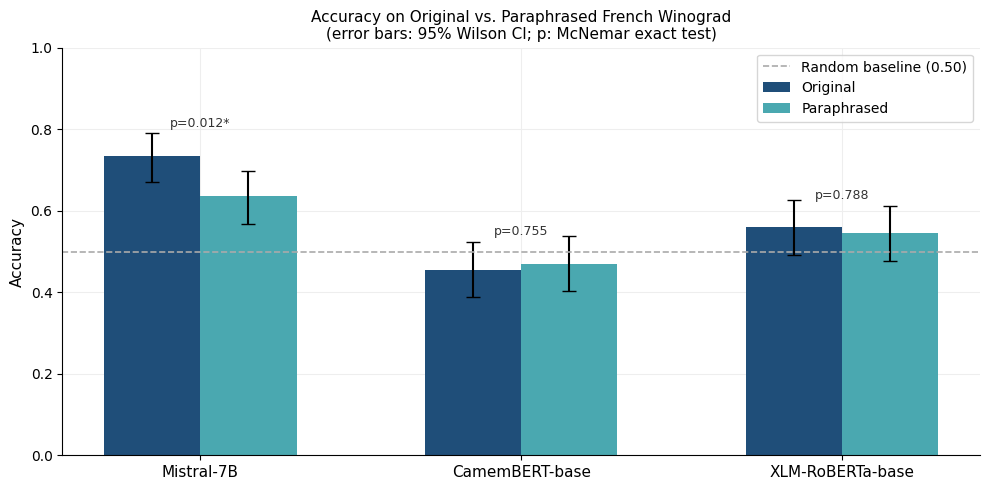

Saved: accuracy_comparison.png


In [34]:
# Figure 1: accuracy on original vs paraphrased for all three models
orig_accs = [orig_acc_mistral, orig_acc_camembert, orig_acc_xlmr]
para_accs = [para_acc_mistral, para_acc_camembert, para_acc_xlmr]
orig_cis  = [orig_ci_mistral,  orig_ci_camembert,  orig_ci_xlmr]
para_cis  = [para_ci_mistral,  para_ci_camembert,  para_ci_xlmr]
pvals     = [pval_mistral,     pval_camembert,     pval_xlmr]

orig_errs = [[orig_accs[i] - orig_cis[i][0] for i in range(3)],
             [orig_cis[i][1] - orig_accs[i] for i in range(3)]]
para_errs = [[para_accs[i] - para_cis[i][0] for i in range(3)],
             [para_cis[i][1] - para_accs[i] for i in range(3)]]

x     = np.arange(3)
width = 0.30

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, orig_accs, width, label="Original",
       color=DARK_BLUE, yerr=orig_errs, capsize=5, error_kw={"elinewidth": 1.5})
ax.bar(x + width/2, para_accs, width, label="Paraphrased",
       color=TEAL, yerr=para_errs, capsize=5, error_kw={"elinewidth": 1.5})
ax.axhline(0.50, color=BASELINE_COLOR, linestyle="--", linewidth=1.2, label="Random baseline (0.50)")

for i, (xpos, pv) in enumerate(zip(x, pvals)):
    y_top = max(orig_accs[i], para_accs[i]) + 0.07
    ax.text(xpos, y_top, f"p={pv:.3f}{'*' if pv < 0.05 else ''}",
            ha="center", fontsize=9, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Accuracy on Original vs. Paraphrased French Winograd\n"
             "(error bars: 95% Wilson CI; p: McNemar exact test)", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "accuracy_comparison.png"), dpi=300)
plt.show()
print("Saved: accuracy_comparison.png")

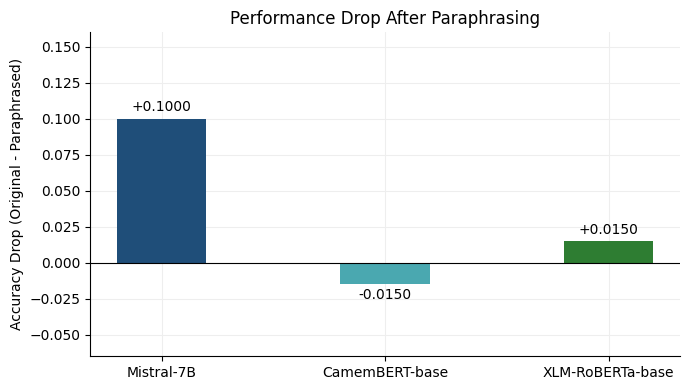

Saved: accuracy_drop.png


In [35]:
# Figure 2: accuracy drop after paraphrasing
drops = [orig_acc_mistral - para_acc_mistral,
         orig_acc_camembert - para_acc_camembert,
         orig_acc_xlmr - para_acc_xlmr]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(MODEL_NAMES, drops, color=MODEL_COLORS, width=0.4)

for bar, d in zip(bars, drops):
    ypos = bar.get_height() + 0.003 if d >= 0 else bar.get_height() - 0.012
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f"{d:+.4f}", ha="center", va="bottom", fontsize=10)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Accuracy Drop (Original - Paraphrased)", fontsize=10)
ax.set_title("Performance Drop After Paraphrasing", fontsize=12)
ax.set_ylim(min(drops) - 0.05, max(drops) + 0.06)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "accuracy_drop.png"), dpi=300)
plt.show()
print("Saved: accuracy_drop.png")

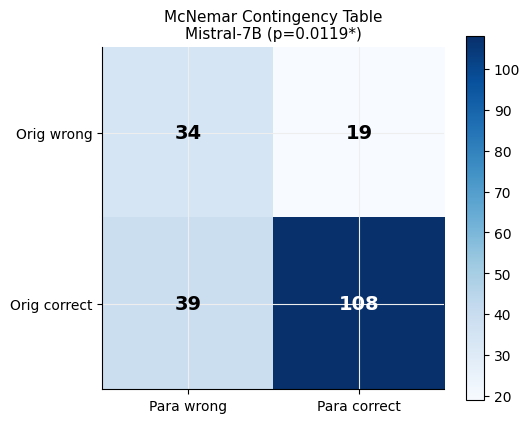

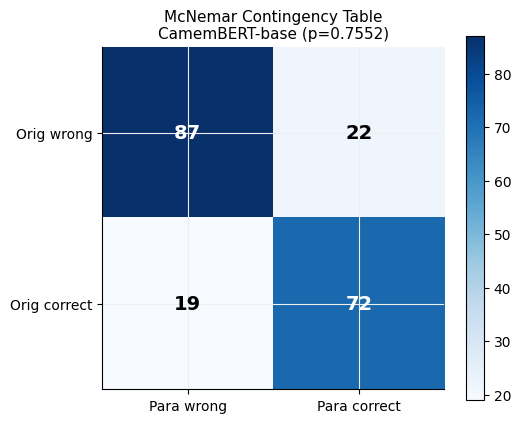

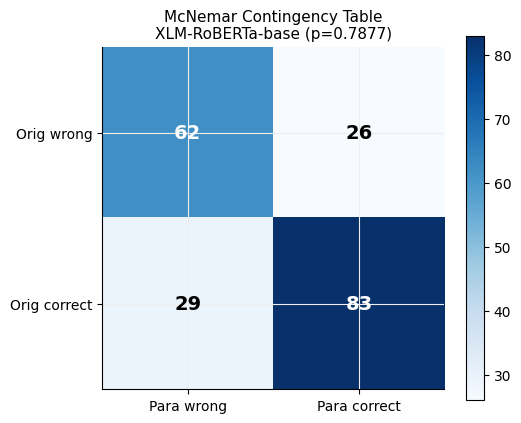

Saved: McNemar heatmaps for all three models


In [36]:
# Figures 3 to 5: McNemar contingency heatmaps per model
def plot_mcnemar_heatmap(table, model_name, pval, filepath):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(table, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Para wrong", "Para correct"], fontsize=10)
    ax.set_yticklabels(["Orig wrong", "Orig correct"], fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(table[i, j]),
                    ha="center", va="center", fontsize=14, fontweight="bold",
                    color="white" if table[i, j] > table.max() * 0.6 else "black")
    sig_str = f" (p={pval:.4f}{'*' if pval < 0.05 else ''})"
    ax.set_title(f"McNemar Contingency Table\n{model_name}{sig_str}", fontsize=11)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300)
    plt.show()

plot_mcnemar_heatmap(table_mistral,   "Mistral-7B",       pval_mistral,
                     os.path.join(figures_dir, "mcnemar_mistral.png"))
plot_mcnemar_heatmap(table_camembert, "CamemBERT-base",   pval_camembert,
                     os.path.join(figures_dir, "mcnemar_camembert.png"))
plot_mcnemar_heatmap(table_xlmr,      "XLM-RoBERTa-base", pval_xlmr,
                     os.path.join(figures_dir, "mcnemar_xlmr.png"))
print("Saved: McNemar heatmaps for all three models")

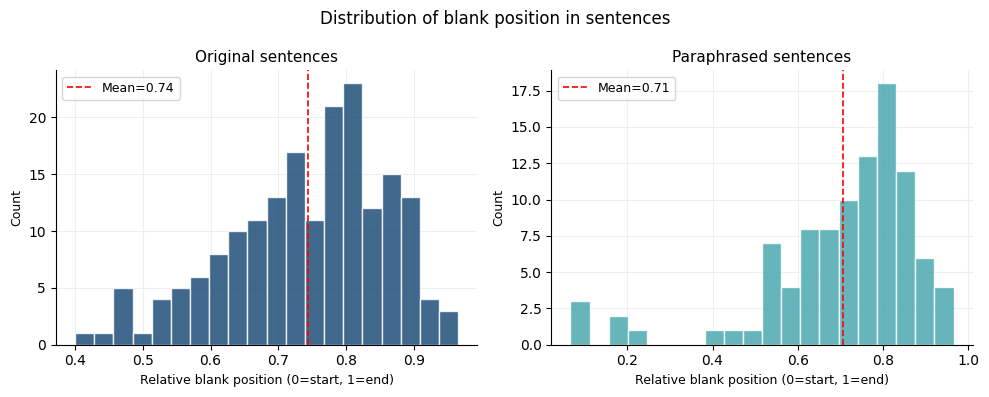

Saved: blank_position_distribution.png


In [37]:
# Figure 6: blank position distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label, color in zip(
    axes,
    ["orig_blank_pos", "para_blank_pos"],
    ["Original sentences", "Paraphrased sentences"],
    [DARK_BLUE, TEAL],
):
    vals = df[col].dropna()
    ax.hist(vals, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="red", linestyle="--",
               linewidth=1.2, label=f"Mean={vals.mean():.2f}")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Relative blank position (0=start, 1=end)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=9)

plt.suptitle("Distribution of blank position in sentences", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "blank_position_distribution.png"), dpi=300)
plt.show()
print("Saved: blank_position_distribution.png")

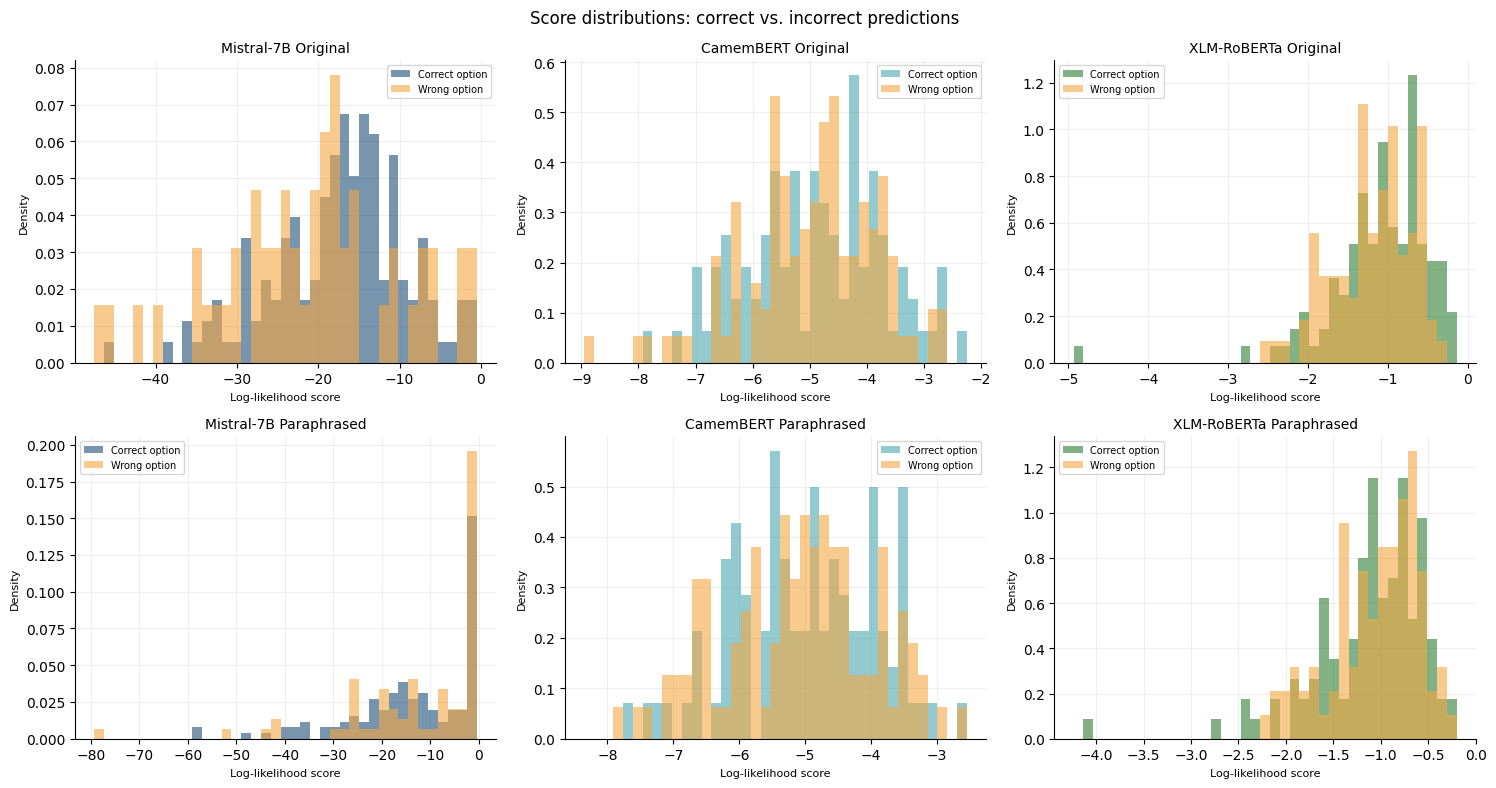

Saved: score_distributions.png


In [38]:
# Figure 7: score distributions for correct vs incorrect predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

pairs = [
    (orig_results_mistral,   "Mistral-7B Original",      DARK_BLUE),
    (orig_results_camembert, "CamemBERT Original",        TEAL),
    (orig_results_xlmr,      "XLM-RoBERTa Original",      GREEN),
    (para_results_mistral,   "Mistral-7B Paraphrased",   DARK_BLUE),
    (para_results_camembert, "CamemBERT Paraphrased",     TEAL),
    (para_results_xlmr,      "XLM-RoBERTa Paraphrased",  GREEN),
]

for idx, (res, title, color) in enumerate(pairs):
    row = idx // 3
    col = idx % 3
    ax  = axes[row, col]

    s1 = res["score1"].replace([np.inf, -np.inf], np.nan).dropna()
    s2 = res["score2"].replace([np.inf, -np.inf], np.nan).dropna()

    if not s1.empty and not s2.empty:
        all_s = pd.concat([s1, s2])
        bins  = np.linspace(all_s.min(), all_s.max(), 40)
        ax.hist(s1[res["correct"] == 1], bins=bins, color=color,  alpha=0.6, label="Correct option", density=True)
        ax.hist(s2[res["correct"] == 0], bins=bins, color=ORANGE, alpha=0.6, label="Wrong option",   density=True)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Log-likelihood score", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle("Score distributions: correct vs. incorrect predictions", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "score_distributions.png"), dpi=300)
plt.show()
print("Saved: score_distributions.png")

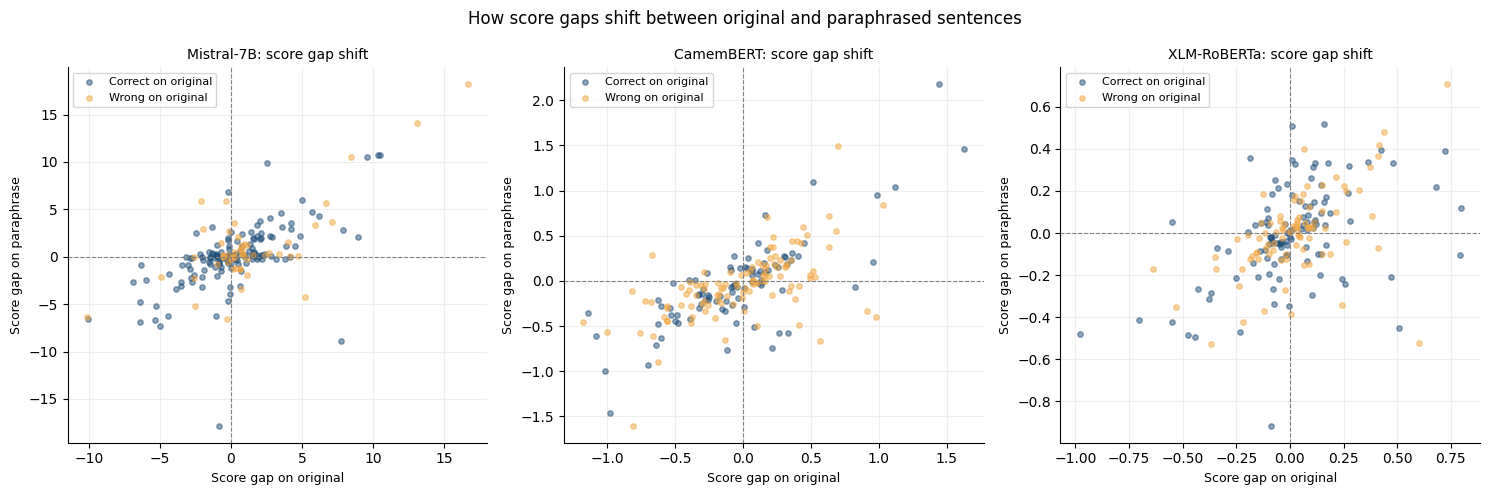

Saved: score_gap_scatter.png


In [39]:
# Figure 8: score gap shift between original and paraphrased conditions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (res_orig, res_para, label) in zip(axes, [
    (orig_results_mistral,   para_results_mistral,   "Mistral-7B"),
    (orig_results_camembert, para_results_camembert, "CamemBERT"),
    (orig_results_xlmr,      para_results_xlmr,      "XLM-RoBERTa"),
]):
    gap_orig = res_orig["score1"] - res_orig["score2"]
    gap_para = res_para["score1"] - res_para["score2"]
    correct  = res_orig["correct"].values

    ax.scatter(gap_orig[correct == 1], gap_para[correct == 1],
               alpha=0.5, s=15, color=DARK_BLUE, label="Correct on original")
    ax.scatter(gap_orig[correct == 0], gap_para[correct == 0],
               alpha=0.5, s=15, color=ORANGE,    label="Wrong on original")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Score gap on original", fontsize=9)
    ax.set_ylabel("Score gap on paraphrase", fontsize=9)
    ax.set_title(f"{label}: score gap shift", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("How score gaps shift between original and paraphrased sentences", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "score_gap_scatter.png"), dpi=300)
plt.show()
print("Saved: score_gap_scatter.png")

## 14. English Sanity Check

Before interpreting the French results, additional sanity checks were performed on a random sample of 50 English WinoWhat instances.

Mistral-7B achieved clearly above-chance performance, indicating that the causal continuation scorer and evaluation pipeline function correctly on the original English benchmark.

An additional sanity check with XLM-RoBERTa-base produced near-chance performance. Since the same pipeline yields strong results for Mistral, this suggests that masked-LM average pseudo-log-likelihood (PLL) scoring is less effective for this task than causal continuation scoring, rather than indicating a general implementation error.

In [13]:
english_path     = "/content/drive/MyDrive/Thesis_2025/new/WinoWhat.csv"
df_english       = pd.read_csv(english_path)
print(f"Full English dataset size: {len(df_english)}")

random.seed(42)
sample_indices    = random.sample(range(len(df_english)), 50)
df_english_sample = df_english.iloc[sample_indices].copy().reset_index(drop=True)
print(f"Sample size: {len(df_english_sample)}")

torch.cuda.empty_cache()

mistral_scorer = CausalPartialScorer("mistralai/Mistral-7B-v0.1")


# SINGLE-EXAMPLE SANITY CHECK

s = df_english_sample.iloc[0]["sentence"]

score1 = mistral_scorer.score_option(
    s,
    df_english_sample.iloc[0]["option1"],
    evaluate_on_full_continuation=True
)

score2 = mistral_scorer.score_option(
    s,
    df_english_sample.iloc[0]["option2"],
    evaluate_on_full_continuation=True
)

print("\nSANITY CHECK")
print("Sentence:", s)
print("Option1:", df_english_sample.iloc[0]["option1"])
print("Option2:", df_english_sample.iloc[0]["option2"])

print("Score1:", score1)
print("Score2:", score2)

pred = 1 if score1 > score2 else 2

print("Prediction:", pred)
print("Gold:", df_english_sample.iloc[0]["answer"])

# FULL EVALUATION

print("\nRunning Mistral on English sample...")

eng_acc, eng_results = evaluate_causal(
    df_english_sample,
    "sentence",
    mistral_scorer
)

eng_ci = wilson_ci(eng_acc, len(df_english_sample))

print()
print(f"English accuracy : {eng_acc:.4f}  95% CI [{eng_ci[0]:.4f}, {eng_ci[1]:.4f}]")
print(f"Random baseline  : 0.5000")

if eng_acc > 0.55:
    print("Scorer works correctly on English.")
else:
    print("Scorer near chance on English — pipeline may still have issues.")

del mistral_scorer
torch.cuda.empty_cache()

Full English dataset size: 1177
Sample size: 50


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)



SANITY CHECK
Sentence: Jill bought a slip to go with her new skirt but the _ was too short and it hung out the bottom.
Option1: skirt
Option2: slip
Score1: -19.018644332885742
Score2: -20.651132583618164
Prediction: 1
Gold: 1

Running Mistral on English sample...


Causal [sentence]:   0%|          | 0/50 [00:00<?, ?it/s]


English accuracy : 0.7800  95% CI [0.6476, 0.8725]
Random baseline  : 0.5000
Scorer works correctly on English.


In [52]:
english_path = "/content/drive/MyDrive/Thesis_2025/new/WinoWhat.csv"
df_english = pd.read_csv(english_path)

print(f"Full English dataset size: {len(df_english)}")

random.seed(42)
sample_indices = random.sample(range(len(df_english)), 50)
df_english_sample = df_english.iloc[sample_indices].copy().reset_index(drop=True)

print(f"Sample size: {len(df_english_sample)}")

torch.cuda.empty_cache()

xlmr_scorer = XLMRobertaScorer("xlm-roberta-base")


# SINGLE-EXAMPLE SANITY CHECK

s = df_english_sample.iloc[0]["sentence"]

filled1 = fill_blank(
    s,
    df_english_sample.iloc[0]["option1"]
)

filled2 = fill_blank(
    s,
    df_english_sample.iloc[0]["option2"]
)

score1 = xlmr_scorer.score(filled1)
score2 = xlmr_scorer.score(filled2)

print("\nSANITY CHECK")
print("Original sentence:", s)
print("Option1:", df_english_sample.iloc[0]["option1"])
print("Option2:", df_english_sample.iloc[0]["option2"])

print("\nFilled option1:", filled1)
print("Filled option2:", filled2)

print("\nScore1:", score1)
print("Score2:", score2)

pred = 1 if score1 > score2 else 2

print("Prediction:", pred)
print("Gold:", df_english_sample.iloc[0]["answer"])


# FULL EVALUATION

print("\nRunning XLM-RoBERTa on English sample...")

eng_acc_xlmr, eng_results_xlmr = evaluate_mlm(
    df_english_sample,
    "sentence",
    xlmr_scorer
)

eng_ci_xlmr = wilson_ci(
    eng_acc_xlmr,
    len(df_english_sample)
)

print()
print(f"English accuracy : {eng_acc_xlmr:.4f}  95% CI [{eng_ci_xlmr[0]:.4f}, {eng_ci_xlmr[1]:.4f}]")
print("Random baseline  : 0.5000")

if eng_acc_xlmr > 0.55:
    print("XLM-R scorer works above chance on English.")
else:
    print("XLM-R scorer is near chance on English.")

del xlmr_scorer
torch.cuda.empty_cache()

Full English dataset size: 1177
Sample size: 50


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from 

  lm_head.decoder.weight shape : torch.Size([250002, 768])
  lm_head.decoder.weight mean  : 0.010872
  lm_head.decoder.weight std   : 0.212022

SANITY CHECK
Original sentence: Jill bought a slip to go with her new skirt but the _ was too short and it hung out the bottom.
Option1: skirt
Option2: slip

Filled option1: Jill bought a slip to go with her new skirt but the skirt was too short and it hung out the bottom.
Filled option2: Jill bought a slip to go with her new skirt but the slip was too short and it hung out the bottom.

Score1: -1.456599402910797
Score2: -1.4796886412029078
Prediction: 1
Gold: 1

Running XLM-RoBERTa on English sample...


MLM [sentence]:   0%|          | 0/50 [00:00<?, ?it/s]


English accuracy : 0.4800  95% CI [0.3480, 0.6149]
Random baseline  : 0.5000
XLM-R scorer is near chance on English.


## 15. Copy Results and Figures to Google Drive

In [40]:
drive_results_dir = "/content/drive/MyDrive/Thesis_2025/new/results"
drive_figures_dir = "/content/drive/MyDrive/Thesis_2025/new/figures"
os.makedirs(drive_results_dir, exist_ok=True)
os.makedirs(drive_figures_dir, exist_ok=True)

result_files = [
    "results_original_mistral.csv",    "results_paraphrased_mistral.csv",
    "wrong_original_mistral.csv",      "wrong_paraphrased_mistral.csv",
    "results_original_camembert.csv",  "results_paraphrased_camembert.csv",
    "wrong_original_camembert.csv",    "wrong_paraphrased_camembert.csv",
    "results_original_xlmr.csv",       "results_paraphrased_xlmr.csv",
    "wrong_original_xlmr.csv",         "wrong_paraphrased_xlmr.csv",
    "summary_results.csv",
]

for fname in result_files:
    src = os.path.join(results_dir, fname)
    dst = os.path.join(drive_results_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Saved: {dst}")
    else:
        print(f"[WARNING] Not found: {src}")

figure_files = [
    "accuracy_comparison.png",
    "accuracy_drop.png",
    "mcnemar_mistral.png",
    "mcnemar_camembert.png",
    "mcnemar_xlmr.png",
    "blank_position_distribution.png",
    "score_distributions.png",
    "score_gap_scatter.png",
]

for fname in figure_files:
    src = os.path.join(figures_dir, fname)
    dst = os.path.join(drive_figures_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Saved: {dst}")
    else:
        print(f"[WARNING] Not found: {src}")

Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_original_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_original_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_paraphrased_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_original_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_original_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_paraphrased_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_original_xlmr.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_xlmr.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_original_xlmr.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_paraphrased_xlmr.csv
Sa

In [54]:
# Qualitative error analysis
import pandas as pd

# Load data
df = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/french_wino_final_with_source.csv")

res = {
    "cam_orig":  pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_camembert.csv"),
    "cam_para":  pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_camembert.csv"),
    "xlmr_orig": pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_xlmr.csv"),
    "xlmr_para": pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_xlmr.csv"),
    "mis_orig":  pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_mistral.csv"),
}

df["cam_orig_ok"]  = res["cam_orig"]["correct"].values
df["cam_para_ok"]  = res["cam_para"]["correct"].values
df["xlmr_orig_ok"] = res["xlmr_orig"]["correct"].values
df["mis_orig_ok"]  = res["mis_orig"]["correct"].values
df["cam_pred"]     = res["cam_orig"]["pred"].values
df["xlmr_pred"]    = res["xlmr_orig"]["pred"].values

def show(rows, n=5):
    for _, r in rows.head(n).iterrows():
        correct = r["option1"] if r["answer"] == 1 else r["option2"]
        print(f"\nID {r['id']} [{r['source']}]")
        print(f"  Original   : {r['sentence']}")
        print(f"  Paraphrase : {r['paraphrased_sentence']}")
        print(f"  Options    : {r['option1']} / {r['option2']}")
        print(f"  Correct    : {correct}")

# Case 1: all three models wrong on original
all_wrong = df[(df["cam_orig_ok"]==0) & (df["xlmr_orig_ok"]==0) & (df["mis_orig_ok"]==0)]
print(f"CASE 1 — All models wrong on original: {len(all_wrong)} instances")
show(all_wrong)

# Case 2: CamemBERT correct on original but wrong on paraphrase
flipped = df[(df["cam_orig_ok"]==1) & (df["cam_para_ok"]==0)]
print(f"\nCASE 2 — CamemBERT flipped correct→wrong after paraphrasing: {len(flipped)} instances")
show(flipped)

# Case 3: CamemBERT and XLM-RoBERTa disagree on original
disagree = df[df["cam_pred"] != df["xlmr_pred"]]
print(f"\nCASE 3 — CamemBERT and XLM-RoBERTa disagree: {len(disagree)} instances")
for _, r in disagree.head(5).iterrows():
    correct  = r["option1"] if r["answer"] == 1 else r["option2"]
    cam_ans  = r["option1"] if r["cam_pred"]  == 1 else r["option2"]
    xlmr_ans = r["option1"] if r["xlmr_pred"] == 1 else r["option2"]
    print(f"\nID {r['id']} [{r['source']}]")
    print(f"  Original    : {r['sentence']}")
    print(f"  Options     : {r['option1']} / {r['option2']}")
    print(f"  Correct     : {correct}")
    print(f"  CamemBERT   : {cam_ans}")
    print(f"  XLM-RoBERTa : {xlmr_ans}")

print(f"\nSummary: all wrong={len(all_wrong)} | flipped={len(flipped)} | disagree={len(disagree)}")

CASE 1 — All models wrong on original: 13 instances

ID 5 [amsili_seminck]
  Original   : Les lycéens harcelaient les collégiens, donc on a punis les _.
  Paraphrase : À cause du harcèlement envers les collégiens, on a finalement sanctionnés les _.
  Options    : collégiens / lycéens
  Correct    : lycéens

ID 62 [amsili_seminck]
  Original   : Anne a demandé à Marie les horaires de fermeture de la bibliothèque, car _ les avait oubliés.
  Paraphrase : Les horaires de fermeture de la bibliothèque ayant été oubliés par _, Anne les a demandés à Marie.
  Options    : Marie / Anne
  Correct    : Anne

ID 100 [winowhat]
  Original   : Lindsey aimait lire des romans graphiques mais Natalie aimait lire de la littérature classique. _ a acheté la nouvelle bande dessinée de Frank Miller à la librairie.
  Paraphrase : Lindsey aimait lire des romans graphiques, mais Natalie préférait la littérature classique. La nouvelle bande dessinée de Frank Miller à la librairie a été achetée par _.
  Options  

In [42]:
# Check for -inf scores across all models and conditions
# These indicate tokenization failures
import pandas as pd

result_files = {
    "Mistral original":     "/content/drive/MyDrive/Thesis_2025/new/results/results_original_mistral.csv",
    "Mistral paraphrased":  "/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_mistral.csv",
    "CamemBERT original":   "/content/drive/MyDrive/Thesis_2025/new/results/results_original_camembert.csv",
    "CamemBERT paraphrased":"/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_camembert.csv",
    "XLM-R original":       "/content/drive/MyDrive/Thesis_2025/new/results/results_original_xlmr.csv",
    "XLM-R paraphrased":    "/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_xlmr.csv",
}

for label, path in result_files.items():
    df = pd.read_csv(path)
    inf_both = df[(df["score1"] == float("-inf")) & (df["score2"] == float("-inf"))]
    inf_s1   = df[(df["score1"] == float("-inf")) & (df["score2"] != float("-inf"))]
    inf_s2   = df[(df["score2"] == float("-inf")) & (df["score1"] != float("-inf"))]
    print(f"{label}:")
    print(f"  Both scores -inf : {len(inf_both)}")
    print(f"  Only score1 -inf : {len(inf_s1)}")
    print(f"  Only score2 -inf : {len(inf_s2)}")
    print()

Mistral original:
  Both scores -inf : 0
  Only score1 -inf : 0
  Only score2 -inf : 0

Mistral paraphrased:
  Both scores -inf : 0
  Only score1 -inf : 0
  Only score2 -inf : 0

CamemBERT original:
  Both scores -inf : 0
  Only score1 -inf : 0
  Only score2 -inf : 0

CamemBERT paraphrased:
  Both scores -inf : 0
  Only score1 -inf : 0
  Only score2 -inf : 0

XLM-R original:
  Both scores -inf : 0
  Only score1 -inf : 0
  Only score2 -inf : 0

XLM-R paraphrased:
  Both scores -inf : 0
  Only score1 -inf : 0
  Only score2 -inf : 0



In [43]:
# Blank position analysis
# Checks whether models perform differently on instances where the blank
# is at the end of the sentence vs mid-sentence.
# This matters because CamemBERT and XLM-RoBERTa use bidirectional
# contex when the blank is mid-sentence they can see words on both
# sides, which may give them an advantage over Mistral.

import pandas as pd
import numpy as np

# Load dataset to get blank positions
df_analysis = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/french_wino_with_paraphrases.csv")

def blank_position_ratio(text):
    """Returns relative position of blank (0=start, 1=end)."""
    if "_" not in str(text):
        return None
    pos = str(text).index("_")
    return pos / len(str(text))

df_analysis["orig_blank_pos"]  = df_analysis["sentence"].apply(blank_position_ratio)
df_analysis["para_blank_pos"]  = df_analysis["paraphrased_sentence"].apply(blank_position_ratio)
df_analysis["para_end_blank"]  = df_analysis["para_blank_pos"] >= 0.85  # True = sentence-final

# Load all result files
results = {
    "Mistral":    (pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_mistral.csv"),
                   pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_mistral.csv")),
    "CamemBERT":  (pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_camembert.csv"),
                   pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_camembert.csv")),
    "XLM-RoBERTa":(pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_xlmr.csv"),
                   pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_xlmr.csv")),
}


print("BLANK POSITION ANALYSIS")
print("Accuracy split by blank position in paraphrased sentences")


for model_name, (orig_df, para_df) in results.items():
    # Merge with blank position info
    para_df = para_df.copy()
    para_df["para_end_blank"] = df_analysis["para_end_blank"].values

    end_blank   = para_df[para_df["para_end_blank"] == True]
    mid_blank   = para_df[para_df["para_end_blank"] == False]

    acc_end = (end_blank["correct"] == 1).mean() if len(end_blank) > 0 else float("nan")
    acc_mid = (mid_blank["correct"] == 1).mean() if len(mid_blank) > 0 else float("nan")

    print(f"\n{model_name}:")
    print(f"  Sentence-final blank (n={len(end_blank):3d}): accuracy = {acc_end:.3f}")
    print(f"  Mid-sentence blank   (n={len(mid_blank):3d}): accuracy = {acc_mid:.3f}")
    print(f"  Difference (end - mid): {acc_end - acc_mid:+.3f}")

print()
print("ORIGINAL sentences: blank position vs accuracy")


for model_name, (orig_df, para_df) in results.items():
    orig_df = orig_df.copy()
    orig_df["orig_blank_pos"] = df_analysis["orig_blank_pos"].values
    orig_df["orig_end_blank"] = orig_df["orig_blank_pos"] >= 0.85

    end_blank = orig_df[orig_df["orig_end_blank"] == True]
    mid_blank = orig_df[orig_df["orig_end_blank"] == False]

    acc_end = (end_blank["correct"] == 1).mean() if len(end_blank) > 0 else float("nan")
    acc_mid = (mid_blank["correct"] == 1).mean() if len(mid_blank) > 0 else float("nan")

    print(f"\n{model_name}:")
    print(f"  Sentence-final blank (n={len(end_blank):3d}): accuracy = {acc_end:.3f}")
    print(f"  Mid-sentence blank   (n={len(mid_blank):3d}): accuracy = {acc_mid:.3f}")
    print(f"  Difference (end - mid): {acc_end - acc_mid:+.3f}")

BLANK POSITION ANALYSIS
Accuracy split by blank position in paraphrased sentences

Mistral:
  Sentence-final blank (n=103): accuracy = 0.553
  Mid-sentence blank   (n= 97): accuracy = 0.722
  Difference (end - mid): -0.168

CamemBERT:
  Sentence-final blank (n=103): accuracy = 0.495
  Mid-sentence blank   (n= 97): accuracy = 0.443
  Difference (end - mid): +0.052

XLM-RoBERTa:
  Sentence-final blank (n=103): accuracy = 0.573
  Mid-sentence blank   (n= 97): accuracy = 0.515
  Difference (end - mid): +0.057

ORIGINAL sentences: blank position vs accuracy

Mistral:
  Sentence-final blank (n= 37): accuracy = 0.595
  Mid-sentence blank   (n=163): accuracy = 0.767
  Difference (end - mid): -0.172

CamemBERT:
  Sentence-final blank (n= 37): accuracy = 0.514
  Mid-sentence blank   (n=163): accuracy = 0.442
  Difference (end - mid): +0.072

XLM-RoBERTa:
  Sentence-final blank (n= 37): accuracy = 0.486
  Mid-sentence blank   (n=163): accuracy = 0.577
  Difference (end - mid): -0.090


In [44]:
#  Answer position and source analysis
import pandas as pd
import numpy as np

df_analysis = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/french_wino_final_with_source.csv")

results = {
    "Mistral": (
        pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_mistral.csv"),
        pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_mistral.csv")
    ),
    "CamemBERT": (
        pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_camembert.csv"),
        pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_camembert.csv")
    ),
    "XLM-RoBERTa": (
        pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_xlmr.csv"),
        pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_xlmr.csv")
    ),
}

# ANALYSIS 2: Answer position (option 1 vs option 2 correct)

print("ANSWER POSITION ANALYSIS")
print("Does accuracy differ depending on which option is correct?")


for model_name, (orig_df, para_df) in results.items():
    orig_df = orig_df.copy()
    para_df = para_df.copy()
    orig_df["answer"] = df_analysis["answer"].values
    para_df["answer"] = df_analysis["answer"].values

    for label, df_r in [("Original", orig_df), ("Paraphrased", para_df)]:
        ans1 = df_r[df_r["answer"] == 1]
        ans2 = df_r[df_r["answer"] == 2]
        acc1 = (ans1["correct"] == 1).mean()
        acc2 = (ans2["correct"] == 1).mean()
        print(f"\n{model_name} — {label}:")
        print(f"  Answer=option1 (n={len(ans1)}): accuracy = {acc1:.3f}")
        print(f"  Answer=option2 (n={len(ans2)}): accuracy = {acc2:.3f}")
        print(f"  Difference (opt1 - opt2): {acc1 - acc2:+.3f}")

# ANALYSIS 3: Source (Amsili & Seminck vs WinoWhat translated)
print()

print("SOURCE ANALYSIS")
print("Do results differ between French-native and translated instances?")


for model_name, (orig_df, para_df) in results.items():
    orig_df = orig_df.copy()
    para_df = para_df.copy()
    orig_df["source"] = df_analysis["source"].values
    para_df["source"] = df_analysis["source"].values

    for label, df_r in [("Original", orig_df), ("Paraphrased", para_df)]:
        as_df  = df_r[df_r["source"] == "amsili_seminck"]
        ww_df  = df_r[df_r["source"] == "winowhat"]
        acc_as = (as_df["correct"] == 1).mean()
        acc_ww = (ww_df["correct"] == 1).mean()
        print(f"\n{model_name} - {label}:")
        print(f"  Amsili & Seminck (n={len(as_df)}): accuracy = {acc_as:.3f}")
        print(f"  WinoWhat translated (n={len(ww_df)}): accuracy = {acc_ww:.3f}")
        print(f"  Difference (AS - WW): {acc_as - acc_ww:+.3f}")

ANSWER POSITION ANALYSIS
Does accuracy differ depending on which option is correct?

Mistral — Original:
  Answer=option1 (n=92): accuracy = 0.815
  Answer=option2 (n=108): accuracy = 0.667
  Difference (opt1 - opt2): +0.149

Mistral — Paraphrased:
  Answer=option1 (n=92): accuracy = 0.707
  Answer=option2 (n=108): accuracy = 0.574
  Difference (opt1 - opt2): +0.132

CamemBERT — Original:
  Answer=option1 (n=92): accuracy = 0.457
  Answer=option2 (n=108): accuracy = 0.454
  Difference (opt1 - opt2): +0.003

CamemBERT — Paraphrased:
  Answer=option1 (n=92): accuracy = 0.370
  Answer=option2 (n=108): accuracy = 0.556
  Difference (opt1 - opt2): -0.186

XLM-RoBERTa — Original:
  Answer=option1 (n=92): accuracy = 0.576
  Answer=option2 (n=108): accuracy = 0.546
  Difference (opt1 - opt2): +0.030

XLM-RoBERTa — Paraphrased:
  Answer=option1 (n=92): accuracy = 0.554
  Answer=option2 (n=108): accuracy = 0.537
  Difference (opt1 - opt2): +0.017

SOURCE ANALYSIS
Do results differ between French

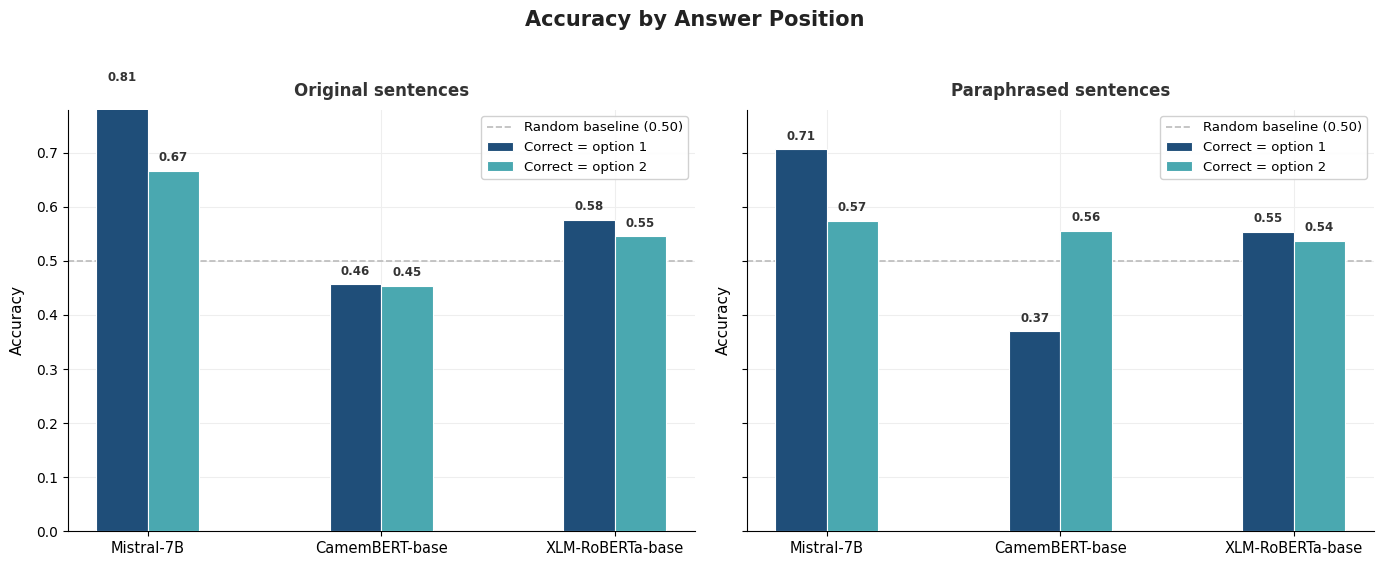

Saved: answer_position.png


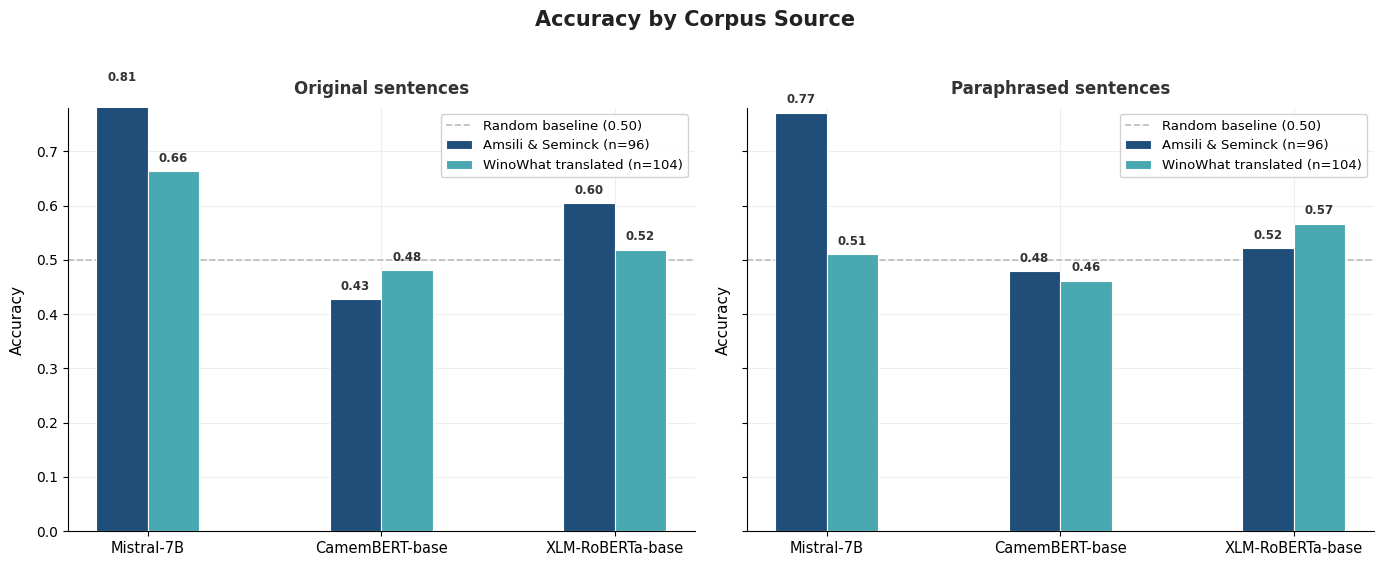

Saved: source_analysis.png


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# style settings
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#eeeeee",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
})

DARK_BLUE  = "#1f4e79"
TEAL       = "#4aa8b0"
BASELINE   = "#bbbbbb"
EDGE       = "white"
models     = ["Mistral-7B", "CamemBERT-base", "XLM-RoBERTa-base"]
x          = np.arange(len(models))
width      = 0.22


#FIGURE 9: Answer Position

# FIGURE 9: Answer Position

opt1_orig = [0.815, 0.457, 0.576]
opt2_orig = [0.667, 0.454, 0.546]

opt1_para = [0.707, 0.370, 0.554]
opt2_para = [0.574, 0.556, 0.537]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
fig.suptitle("Accuracy by Answer Position", fontsize=15,
             fontweight="bold", y=1.02, color="#222222")

for ax, opt1, opt2, condition in zip(
    axes,
    [opt1_orig, opt1_para],
    [opt2_orig, opt2_para],
    ["Original sentences", "Paraphrased sentences"]
):
    bars1 = ax.bar(x - width/2, opt1, width, label="Correct = option 1",
                   color=DARK_BLUE, edgecolor=EDGE, linewidth=0.8, zorder=3)
    bars2 = ax.bar(x + width/2, opt2, width, label="Correct = option 2",
                   color=TEAL, edgecolor=EDGE, linewidth=0.8, zorder=3)

    ax.axhline(0.5, color=BASELINE, linestyle="--", linewidth=1.2,
               label="Random baseline (0.50)", zorder=2)

    ax.set_title(condition, fontsize=12, fontweight="bold",
                 color="#333333", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10.5)
    ax.set_ylim(0, 0.78)
    ax.set_ylabel("Accuracy", fontsize=11, labelpad=8)
    ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
    ax.legend(fontsize=9.5, framealpha=0.9, edgecolor="#cccccc",
              loc="upper right")

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{bar.get_height():.2f}",
                ha="center", va="bottom", fontsize=8.5,
                color="#333333", fontweight="bold")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Thesis_2025/new/figures/answer_position.png",
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: answer_position.png")


# FIGURE 10: Source Analysis

as_orig = [0.812, 0.427, 0.604]
ww_orig = [0.663, 0.481, 0.519]

as_para = [0.771, 0.479, 0.521]
ww_para = [0.510, 0.462, 0.567]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
fig.suptitle("Accuracy by Corpus Source", fontsize=15,
             fontweight="bold", y=1.02, color="#222222")

for ax, as_acc, ww_acc, condition in zip(
    axes,
    [as_orig, as_para],
    [ww_orig, ww_para],
    ["Original sentences", "Paraphrased sentences"]
):
    bars1 = ax.bar(x - width/2, as_acc, width,
                   label="Amsili & Seminck (n=96)",
                   color=DARK_BLUE, edgecolor=EDGE, linewidth=0.8, zorder=3)
    bars2 = ax.bar(x + width/2, ww_acc, width,
                   label="WinoWhat translated (n=104)",
                   color=TEAL, edgecolor=EDGE, linewidth=0.8, zorder=3)

    ax.axhline(0.5, color=BASELINE, linestyle="--", linewidth=1.2,
               label="Random baseline (0.50)", zorder=2)

    ax.set_title(condition, fontsize=12, fontweight="bold",
                 color="#333333", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=10.5)
    ax.set_ylim(0, 0.78)
    ax.set_ylabel("Accuracy", fontsize=11, labelpad=8)
    ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
    ax.legend(fontsize=9.5, framealpha=0.9, edgecolor="#cccccc",
              loc="upper right")

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{bar.get_height():.2f}",
                ha="center", va="bottom", fontsize=8.5,
                color="#333333", fontweight="bold")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Thesis_2025/new/figures/source_analysis.png",
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: source_analysis.png")

In [55]:
# Option length analysis
# In the original WinoWhat dataset options are always one word.
# In French, grammatical gender means the article (le, la, les, un,
# une, des, l') must be included with the noun, so many options are
# two words instead of one. This checks whether two-word options are
# harder for models to score correctly.

FRENCH_ARTICLES = {"le", "la", "les", "un", "une", "des", "l'"}

def is_two_word_option(text):
    """True if the option starts with a French article followed by a noun."""
    parts = str(text).strip().split()
    if len(parts) < 2:
        return False
    return parts[0].lower().rstrip("'") in {a.rstrip("'") for a in FRENCH_ARTICLES} \
           or parts[0].lower() in FRENCH_ARTICLES

df["opt1_is_two_word"] = df["option1"].apply(is_two_word_option)
df["opt2_is_two_word"] = df["option2"].apply(is_two_word_option)

# An instance is "two-word" if the correct option is two words
df["correct_opt_text"] = df.apply(
    lambda r: r["option1"] if r["answer"] == 1 else r["option2"], axis=1
)
df["correct_is_two_word"] = df["correct_opt_text"].apply(is_two_word_option)

# Also flag instances where EITHER option is two words
df["any_two_word"] = df["opt1_is_two_word"] | df["opt2_is_two_word"]
df["both_two_word"] = df["opt1_is_two_word"] & df["opt2_is_two_word"]

print("OPTION LENGTH OVERVIEW")
print(f"  Total instances                : {len(df)}")
print(f"  Option 1 is two words          : {df['opt1_is_two_word'].sum()} ({df['opt1_is_two_word'].mean()*100:.1f}%)")
print(f"  Option 2 is two words          : {df['opt2_is_two_word'].sum()} ({df['opt2_is_two_word'].mean()*100:.1f}%)")
print(f"  Correct option is two words    : {df['correct_is_two_word'].sum()} ({df['correct_is_two_word'].mean()*100:.1f}%)")
print(f"  At least one option two words  : {df['any_two_word'].sum()} ({df['any_two_word'].mean()*100:.1f}%)")
print(f"  Both options two words         : {df['both_two_word'].sum()} ({df['both_two_word'].mean()*100:.1f}%)")
print()

# Show split examples
print("Examples of two-word options:")
for _, r in df[df["any_two_word"]].head(5).iterrows():
    print(f"  ID {r['id']}: opt1='{r['option1']}'  opt2='{r['option2']}'  answer={r['answer']}")
print()

# Accuracy split: one-word correct option vs two-word correct option
results_to_check = {
    "Mistral orig":    orig_results_mistral,
    "Mistral para":    para_results_mistral,
    "CamemBERT orig":  orig_results_camembert,
    "CamemBERT para":  para_results_camembert,
    "XLM-R orig":      orig_results_xlmr,
    "XLM-R para":      para_results_xlmr,
}

print("ACCURACY BY CORRECT OPTION LENGTH")
print(f"{'Condition':<20} {'1-word correct':>16} {'2-word correct':>16} {'Difference':>12}")
print("-" * 68)

two_word_mask = df["correct_is_two_word"].values

for label, res in results_to_check.items():
    correct = res["correct"].values
    acc_one = correct[~two_word_mask].mean() if (~two_word_mask).sum() > 0 else float("nan")
    acc_two = correct[two_word_mask].mean()  if two_word_mask.sum() > 0 else float("nan")
    n_one   = (~two_word_mask).sum()
    n_two   = two_word_mask.sum()
    diff    = acc_two - acc_one
    print(f"{label:<20} {acc_one:>6.3f} (n={n_one:<4}) {acc_two:>6.3f} (n={n_two:<4}) {diff:>+10.3f}")

print()

# Also split by whether EITHER option is two words (i.e. the pair is mixed/asymmetric)
print("ACCURACY BY INSTANCE TYPE")
print("  one-word  = both options are one word")
print("  mixed     = one option is one word, the other is two words")
print("  both two  = both options are two words")
print()

one_word_mask  = ~df["any_two_word"].values
mixed_mask     = df["any_two_word"].values & ~df["both_two_word"].values
both_two_mask  = df["both_two_word"].values

print(f"{'Condition':<20} {'one-word':>14} {'mixed':>14} {'both-two':>14}")
print("-" * 65)

for label, res in results_to_check.items():
    correct  = res["correct"].values
    acc_ow   = correct[one_word_mask].mean()  if one_word_mask.sum()  > 0 else float("nan")
    acc_mix  = correct[mixed_mask].mean()     if mixed_mask.sum()     > 0 else float("nan")
    acc_bt   = correct[both_two_mask].mean()  if both_two_mask.sum()  > 0 else float("nan")
    n_ow     = one_word_mask.sum()
    n_mix    = mixed_mask.sum()
    n_bt     = both_two_mask.sum()
    print(f"{label:<20} {acc_ow:>5.3f} (n={n_ow:<3}) {acc_mix:>5.3f} (n={n_mix:<3}) {acc_bt:>5.3f} (n={n_bt:<3})")

OPTION LENGTH OVERVIEW
  Total instances                : 200
  Option 1 is two words          : 24 (12.0%)
  Option 2 is two words          : 19 (9.5%)
  Correct option is two words    : 20 (10.0%)
  At least one option two words  : 35 (17.5%)
  Both options two words         : 8 (4.0%)

Examples of two-word options:
  ID 3: opt1='l'avocat'  opt2='le témoin'  answer=1
  ID 11: opt1='le toit'  opt2='l'arbre'  answer=2
  ID 18: opt1='le lac'  opt2='la mer'  answer=1
  ID 19: opt1='les manteaux'  opt2='Fred et Alice'  answer=2
  ID 27: opt1='le Kamchatka'  opt2='Yakoutsk'  answer=2

ACCURACY BY CORRECT OPTION LENGTH
Condition              1-word correct   2-word correct   Difference
--------------------------------------------------------------------
Mistral orig          0.744 (n=180 )  0.650 (n=20  )     -0.094
Mistral para          0.633 (n=180 )  0.650 (n=20  )     +0.017
CamemBERT orig        0.444 (n=180 )  0.550 (n=20  )     +0.106
CamemBERT para        0.450 (n=180 )  0.650 (n=20

In [47]:
# Check for exact score ties across all models and conditions
print("EXACT SCORE TIES")
print("-" * 40)

checks = [
    ("Mistral orig",    orig_results_mistral),
    ("Mistral para",    para_results_mistral),
    ("CamemBERT orig",  orig_results_camembert),
    ("CamemBERT para",  para_results_camembert),
    ("XLM-R orig",      orig_results_xlmr),
    ("XLM-R para",      para_results_xlmr),
]

for label, res in checks:
    ties = res[res["score1"] == res["score2"]]
    print(f"{label:<20}: {len(ties)} tie(s)")
    if len(ties) > 0:
      print(ties[["id", "score1", "score2", "pred", "answer"]].to_string())

EXACT SCORE TIES
----------------------------------------
Mistral orig        : 0 tie(s)
Mistral para        : 0 tie(s)
CamemBERT orig      : 0 tie(s)
CamemBERT para      : 0 tie(s)
XLM-R orig          : 0 tie(s)
XLM-R para          : 0 tie(s)


In [57]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/french_wino_with_paraphrases.csv")

FRENCH_ARTICLES = {"le", "la", "les", "un", "une", "des", "l'", "l'"}

def starts_with_article(text):
    text = str(text).strip()
    first_word = text.split()[0].lower() if text.split() else ""
    # handle l' with apostrophe variants
    if first_word.startswith("l'") or first_word.startswith("l'"):
        return True
    return first_word in FRENCH_ARTICLES

def get_article(text):
    text = str(text).strip()
    first_word = text.split()[0].lower() if text.split() else ""
    if first_word.startswith("l'") or first_word.startswith("l'"):
        return "l'"
    return first_word if first_word in FRENCH_ARTICLES else None

df["opt1_has_article"] = df["option1"].apply(starts_with_article)
df["opt2_has_article"] = df["option2"].apply(starts_with_article)
df["opt1_article"]     = df["option1"].apply(get_article)
df["opt2_article"]     = df["option2"].apply(get_article)

df["both_have_article"]    = df["opt1_has_article"] & df["opt2_has_article"]
df["same_article"]         = df.apply(
    lambda r: r["opt1_article"] == r["opt2_article"]
              if r["both_have_article"] else False, axis=1
)
df["different_article"]    = df["both_have_article"] & ~df["same_article"]
df["only_opt1_article"]    = df["opt1_has_article"] & ~df["opt2_has_article"]
df["only_opt2_article"]    = df["opt2_has_article"] & ~df["opt1_has_article"]
df["neither_has_article"]  = ~df["opt1_has_article"] & ~df["opt2_has_article"]

print("OPTION ARTICLE OVERVIEW")
print(f"  Total instances                        : {len(df)}")
print(f"  Option 1 starts with article           : {df['opt1_has_article'].sum()} ({df['opt1_has_article'].mean()*100:.1f}%)")
print(f"  Option 2 starts with article           : {df['opt2_has_article'].sum()} ({df['opt2_has_article'].mean()*100:.1f}%)")
print(f"  Both options have article              : {df['both_have_article'].sum()} ({df['both_have_article'].mean()*100:.1f}%)")
print(f"    - Same article (no gender cue)       : {df['same_article'].sum()} ({df['same_article'].mean()*100:.1f}%)")
print(f"    - Different article (gender cue)     : {df['different_article'].sum()} ({df['different_article'].mean()*100:.1f}%)")
print(f"  Only option 1 has article              : {df['only_opt1_article'].sum()} ({df['only_opt1_article'].mean()*100:.1f}%)")
print(f"  Only option 2 has article              : {df['only_opt2_article'].sum()} ({df['only_opt2_article'].mean()*100:.1f}%)")
print(f"  Neither option has article             : {df['neither_has_article'].sum()} ({df['neither_has_article'].mean()*100:.1f}%)")

print()
print("INSTANCES WHERE DIFFERENT ARTICLES REVEAL GENDER CUE:")
gender_cue = df[df["different_article"]]
for _, r in gender_cue.iterrows():
    print(f"  ID {r['id']}: opt1='{r['option1']}'  opt2='{r['option2']}'  answer={r['answer']}")

print()
print("ARTICLE FREQUENCY BREAKDOWN:")
all_articles = pd.concat([
    df[df["opt1_has_article"]]["opt1_article"],
    df[df["opt2_has_article"]]["opt2_article"]
])
print(all_articles.value_counts().to_string())

print()
print("OPTION WORD COUNT BREAKDOWN:")

def word_count(text):
    return len(str(text).strip().split())

df["opt1_words"] = df["option1"].apply(word_count)
df["opt2_words"] = df["option2"].apply(word_count)
df["correct_opt_text"] = df.apply(
    lambda r: r["option1"] if r["answer"] == 1 else r["option2"], axis=1
)
df["correct_opt_words"] = df["correct_opt_text"].apply(word_count)
df["max_opt_words"] = df[["opt1_words", "opt2_words"]].max(axis=1)

print(f"  1-word options (both)    : {(df['opt1_words'] == 1).sum()} opt1 / {(df['opt2_words'] == 1).sum()} opt2")
print(f"  2-word options (both)    : {(df['opt1_words'] == 2).sum()} opt1 / {(df['opt2_words'] == 2).sum()} opt2")
print(f"  3+ word options (both)   : {(df['opt1_words'] >= 3).sum()} opt1 / {(df['opt2_words'] >= 3).sum()} opt2")

print()
print(f"  Instances where at least one option is 3+ words : {(df['max_opt_words'] >= 3).sum()}")
print(f"  Instances where correct option is 3+ words      : {(df['correct_opt_words'] >= 3).sum()}")

print()
print("3+ WORD OPTION INSTANCES:")
three_plus = df[df["max_opt_words"] >= 3]
for _, r in three_plus.iterrows():
    print(f"  ID {r['id']}: opt1='{r['option1']}' ({r['opt1_words']}w)  "
          f"opt2='{r['option2']}' ({r['opt2_words']}w)  answer={r['answer']}")

OPTION ARTICLE OVERVIEW
  Total instances                        : 200
  Option 1 starts with article           : 29 (14.5%)
  Option 2 starts with article           : 28 (14.0%)
  Both options have article              : 20 (10.0%)
    - Same article (no gender cue)       : 1 (0.5%)
    - Different article (gender cue)     : 19 (9.5%)
  Only option 1 has article              : 9 (4.5%)
  Only option 2 has article              : 8 (4.0%)
  Neither option has article             : 163 (81.5%)

INSTANCES WHERE DIFFERENT ARTICLES REVEAL GENDER CUE:
  ID 3: opt1='l'avocat'  opt2='le témoin'  answer=1
  ID 11: opt1='le toit'  opt2='l'arbre'  answer=2
  ID 18: opt1='le lac'  opt2='la mer'  answer=1
  ID 30: opt1='le gang'  opt2='la police'  answer=2
  ID 53: opt1='la sculpture'  opt2='l'étagère'  answer=1
  ID 63: opt1='la carafe'  opt2='l'étagère'  answer=1
  ID 72: opt1='l'article'  opt2='le livre'  answer=2
  ID 79: opt1='la carafe'  opt2='l'éponge'  answer=2
  ID 89: opt1='le tableau'  o

In [58]:
import pandas as pd
import numpy as np

# Load results
orig_mistral    = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_mistral.csv")
para_mistral    = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_mistral.csv")
orig_camembert  = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_camembert.csv")
para_camembert  = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_camembert.csv")
orig_xlmr       = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_original_xlmr.csv")
para_xlmr       = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_xlmr.csv")

# Rebuild article flags from the dataset
df = pd.read_csv("/content/drive/MyDrive/Thesis_2025/new/french_wino_with_paraphrases.csv")

FRENCH_ARTICLES = {"le", "la", "les", "un", "une", "des", "l'", "l\u2019"}

def starts_with_article(text):
    text = str(text).strip()
    first_word = text.split()[0].lower() if text.split() else ""
    if first_word.startswith("l'") or first_word.startswith("l\u2019"):
        return True
    return first_word in FRENCH_ARTICLES

def get_article(text):
    text = str(text).strip()
    first_word = text.split()[0].lower() if text.split() else ""
    if first_word.startswith("l'") or first_word.startswith("l\u2019"):
        return "l'"
    return first_word if first_word in FRENCH_ARTICLES else None

df["opt1_has_article"] = df["option1"].apply(starts_with_article)
df["opt2_has_article"] = df["option2"].apply(starts_with_article)
df["opt1_article"]     = df["option1"].apply(get_article)
df["opt2_article"]     = df["option2"].apply(get_article)
df["both_have_article"]  = df["opt1_has_article"] & df["opt2_has_article"]
df["different_article"]  = df["both_have_article"] & (df["opt1_article"] != df["opt2_article"])

gender_cue_mask = df["different_article"].values
no_cue_mask     = ~gender_cue_mask

n_cue    = gender_cue_mask.sum()
n_no_cue = no_cue_mask.sum()

results = {
    "Mistral orig":   orig_mistral,
    "Mistral para":   para_mistral,
    "CamemBERT orig": orig_camembert,
    "CamemBERT para": para_camembert,
    "XLM-R orig":     orig_xlmr,
    "XLM-R para":     para_xlmr,
}

print("GENDER CUE ANALYSIS")
print(f"Instances with different articles (gender cue) : {n_cue}")
print(f"Instances without gender cue                   : {n_no_cue}")
print()
print(f"{'Condition':<20} {'No cue':>12} {'Gender cue':>12} {'Difference':>12}")
print("-" * 58)

for label, res in results.items():
    correct = res["correct"].values
    acc_no_cue  = correct[no_cue_mask].mean()
    acc_cue     = correct[gender_cue_mask].mean()
    diff        = acc_cue - acc_no_cue
    print(f"{label:<20} {acc_no_cue:>7.3f} (n={n_no_cue:<3}) "
          f"{acc_cue:>7.3f} (n={n_cue:<3}) {diff:>+10.3f}")

print()
print("INDIVIDUAL GENDER CUE INSTANCES:")
cue_ids = df[df["different_article"]]["id"].values
print(f"IDs: {list(cue_ids)}")
print()

# Show per-instance breakdown for cue instances
print(f"{'ID':<6} {'opt1':<20} {'opt2':<20} {'ans':<5} "
      f"{'M_o':<5} {'M_p':<5} {'C_o':<5} {'C_p':<5} "
      f"{'X_o':<5} {'X_p':<5}")
print("-" * 75)

cue_df = df[df["different_article"]].copy()
for _, row in cue_df.iterrows():
    idx = df[df["id"] == row["id"]].index[0]
    mo = orig_mistral.iloc[idx]["correct"]
    mp = para_mistral.iloc[idx]["correct"]
    co = orig_camembert.iloc[idx]["correct"]
    cp = para_camembert.iloc[idx]["correct"]
    xo = orig_xlmr.iloc[idx]["correct"]
    xp = para_xlmr.iloc[idx]["correct"]
    print(f"{row['id']:<6} {str(row['option1']):<20} {str(row['option2']):<20} "
          f"{row['answer']:<5} {mo:<5} {mp:<5} {co:<5} {cp:<5} {xo:<5} {xp:<5}")

GENDER CUE ANALYSIS
Instances with different articles (gender cue) : 19
Instances without gender cue                   : 181

Condition                  No cue   Gender cue   Difference
----------------------------------------------------------
Mistral orig           0.746 (n=181)   0.632 (n=19 )     -0.114
Mistral para           0.635 (n=181)   0.632 (n=19 )     -0.004
CamemBERT orig         0.453 (n=181)   0.474 (n=19 )     +0.021
CamemBERT para         0.453 (n=181)   0.632 (n=19 )     +0.179
XLM-R orig             0.569 (n=181)   0.474 (n=19 )     -0.095
XLM-R para             0.547 (n=181)   0.526 (n=19 )     -0.021

INDIVIDUAL GENDER CUE INSTANCES:
IDs: [np.int64(3), np.int64(11), np.int64(18), np.int64(30), np.int64(53), np.int64(63), np.int64(72), np.int64(79), np.int64(89), np.int64(99), np.int64(105), np.int64(107), np.int64(108), np.int64(109), np.int64(115), np.int64(116), np.int64(181), np.int64(189), np.int64(190)]

ID     opt1                 opt2                 ans   M

In [1]:
# login to Hugging Face

from huggingface_hub import login
from getpass import getpass

hf_token = getpass("Paste your Hugging Face token: ")
login(token=hf_token)

Paste your Hugging Face token: ··········


In [23]:
# Llama-2 English sanity check on 50 WinoWhat items

import random
import pandas as pd
import torch

english_path = "/content/drive/MyDrive/Thesis_2025/new/WinoWhat.csv"
df_english = pd.read_csv(english_path)

print(f"Full English dataset size: {len(df_english)}")

random.seed(42)
sample_indices = random.sample(range(len(df_english)), 50)
df_english_sample = df_english.iloc[sample_indices].copy().reset_index(drop=True)

print(f"Sample size: {len(df_english_sample)}")

torch.cuda.empty_cache()

llama_scorer = CausalPartialScorer("meta-llama/Llama-2-7b-hf")

Full English dataset size: 1177
Sample size: 50


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [24]:
# single example sanity check

s = df_english_sample.iloc[0]["sentence"]

score1 = llama_scorer.score_option(
    s,
    df_english_sample.iloc[0]["option1"],
    evaluate_on_full_continuation=True
)

score2 = llama_scorer.score_option(
    s,
    df_english_sample.iloc[0]["option2"],
    evaluate_on_full_continuation=True
)

pred = 1 if score1 > score2 else 2

print("\nSANITY CHECK")
print("Sentence:", s)
print("Option1:", df_english_sample.iloc[0]["option1"])
print("Option2:", df_english_sample.iloc[0]["option2"])
print("Score1:", score1)
print("Score2:", score2)
print("Prediction:", pred)
print("Gold:", df_english_sample.iloc[0]["answer"])


SANITY CHECK
Sentence: Jill bought a slip to go with her new skirt but the _ was too short and it hung out the bottom.
Option1: skirt
Option2: slip
Score1: -23.096176147460938
Score2: -23.361631393432617
Prediction: 1
Gold: 1


In [25]:
# full 50-item sanity check

print("\nRunning Llama-2-7B on English sample...")

llama_eng_acc, llama_eng_results = evaluate_causal(
    df_english_sample,
    "sentence",
    llama_scorer
)

llama_eng_ci = wilson_ci(
    llama_eng_acc,
    len(df_english_sample)
)

print()
print(f"English accuracy : {llama_eng_acc:.4f}  95% CI [{llama_eng_ci[0]:.4f}, {llama_eng_ci[1]:.4f}]")
print("Random baseline  : 0.5000")

if llama_eng_acc > 0.55:
    print("Llama-2 scorer works above chance on English.")
else:
    print("Llama-2 scorer is near chance on English.")


Running Llama-2-7B on English sample...


Causal [sentence]:   0%|          | 0/50 [00:00<?, ?it/s]


English accuracy : 0.7200  95% CI [0.5833, 0.8253]
Random baseline  : 0.5000
Llama-2 scorer works above chance on English.


In [26]:
# cleanup

del llama_scorer
torch.cuda.empty_cache()

## References

Amsili, P., and Seminck, O. (2017). A Google-proof collection of French Winograd schemas. CORBON 2017, 24-29.

Gevers, I., De Marez, V., De Bruyne, L., and Daelemans, W. (2025). WinoWhat: A parallel corpus of paraphrased WinoGrande sentences with common sense categorization. CoNLL 2025, 68-80.

Martin, L., et al. (2020). CamemBERT: A tasty French language model. ACL 2020, 7203-7219.

Jiang, A. Q., et al. (2023). Mistral 7B. arXiv:2310.06825.

Conneau, A., et al. (2020). Unsupervised cross-lingual representation learning at scale. ACL 2020, 8440-8451.

Salazar, J., et al. (2020). Masked language model scoring. ACL 2020, 2699-2712.